In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
spark = SparkSession.builder \
    .appName("Segmentacion_Perfilado_Clientes") \
    .getOrCreate()

clientes_df = spark.read.parquet("/home/jovyan/work/data/CLIENTS", header=True, inferSchema=True)
behavioural_df = spark.read.parquet("/home/jovyan/work/data/BEHAVIOURAL", header=True, inferSchema=True)

only_clientes_df = spark.read.parquet("/home/jovyan/work/data/solo_cli", header=True, inferSchema=True)
only_behavioural_df = spark.read.parquet("/home/jovyan/work/data/solo_beh", header=True, inferSchema=True)

comunes_df = spark.read.parquet("/home/jovyan/work/data/COMUNES", header=True, inferSchema=True)

In [3]:
behavioural_df

DataFrame[CONTRACT_ID: string, CLIENT_ID: string, DATE: date, CREDICT_CARD_BALANCE: double, CREDIT_CARD_LIMIT: double, CREDIT_CARD_DRAWINGS_ATM: double, CREDIT_CARD_DRAWINGS: double, CREDIT_CARD_DRAWINGS_POS: double, CREDIT_CARD_DRAWINGS_OTHER: double, CREDIT_CARD_PAYMENT: double, NUMBER_DRAWINGS_ATM: double, NUMBER_DRAWINGS: int, NUMBER_INSTALMENTS: double, CURRENCY: string]

In [4]:
clientes_df

DataFrame[CLIENT_ID: string, NON_COMPLIANT_CONTRACT: int, NAME_PRODUCT_TYPE: string, GENDER: string, TOTAL_INCOME: double, AMOUNT_PRODUCT: double, INSTALLMENT: double, EDUCATION: string, MARITAL_STATUS: string, HOME_SITUATION: string, REGION_SCORE: double, AGE_IN_YEARS: double, JOB_SENIORITY: double, HOME_SENIORITY: double, LAST_UPDATE: double, OWN_INSURANCE_CAR: string, CAR_AGE: double, FAMILY_SIZE: double, REACTIVE_SCORING: double, PROACTIVE_SCORING: double, BEHAVIORAL_SCORING: double, DAYS_LAST_INFO_CHANGE: double, NUMBER_OF_PRODUCTS: double, OCCUPATION: string, DIGITAL_CLIENT: int, HOME_OWNER: string, EMPLOYER_ORGANIZATION_TYPE: string, CURRENCY: string, NUM_PREVIOUS_LOAN_APP: double, LOAN_ANNUITY_PAYMENT_MAX: double, LOAN_ANNUITY_PAYMENT_MIN: double, LOAN_ANNUITY_PAYMENT_SUM: double, LOAN_APPLICATION_AMOUNT_MAX: double, LOAN_APPLICATION_AMOUNT_MIN: double, LOAN_APPLICATION_AMOUNT_SUM: double, LOAN_CREDIT_GRANTED_MAX: double, LOAN_CREDIT_GRANTED_MIN: double, LOAN_CREDIT_GRANTED_SUM

# METRICAS

# Estos son los clientes Prime


In [5]:
#CAQ = Customer Acquisition Quality

df_id_clientes_behavioural = clientes_df.alias("c").join(
    behavioural_df.alias("b"),
    on="CLIENT_ID",
    how="inner"
)


# Asumimos que df_id_clientes_behavioural ya fue creado correctamente (sin el .show(5))

# 1. Calcular el Payment Ratio (Pago / Saldo Pendiente)
df_features = df_id_clientes_behavioural.withColumn(
    "PAYMENT_RATIO",
    F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE")
)

# 2. Manejar Nulls/Division por Cero (CORREGIDO el error lógico)
# Aseguramos que (F.col("CREDICT_CARD_BALANCE") == 0) sea una expresión BOOLEAN
df_features = df_features.withColumn(
    "PAYMENT_RATIO",
    F.when(
        (F.col("PAYMENT_RATIO").isNull()) | (F.col("CREDICT_CARD_BALANCE") == 0), 1.0
    ).otherwise(F.col("PAYMENT_RATIO"))
)

# 3. Calcular Umbrales (Q75) - Usando TOTAL_INCOME
quantile_list = [0.75]

quantiles = df_features.approxQuantile(
    ["TOTAL_INCOME", "CREDIT_CARD_LIMIT", "PAYMENT_RATIO"], 
    quantile_list,
    0.01
)

# Extraer los umbrales
income_q75 = quantiles[0][0]
limit_q75 = quantiles[1][0]
ratio_q75 = quantiles[2][0]

print(f"Umbral de Ingreso (Q75): {income_q75:,.2f}")
print(f"Umbral de Límite (Q75): {limit_q75:,.2f}")
print(f"Umbral de Ratio de Pago (Q75): {ratio_q75:,.2f}")

# 4. Filtrar y Segmentar el Perfil CAQ
df_caq_profile = df_features.filter(
    (F.col("TOTAL_INCOME") >= income_q75) &           # Ingresos Altos
    (F.col("CREDIT_CARD_LIMIT") >= limit_q75) &       # Límites Altos
    (F.col("PAYMENT_RATIO") >= 1.0)                   # Sin Atrasos (Pagan al menos el 100% de la deuda)
)

print(f"Total de clientes en el perfil CAQ: {df_caq_profile.count()}")
df_caq_profile.show(5)

print("Porcentaje de clientes en el perfil CAQ:")
total_clients = clientes_df.select("CLIENT_ID").distinct().count()
caq_clients = df_caq_profile.select("CLIENT_ID").distinct().count()
percentage_caq = (caq_clients / total_clients) * 100
print(f"{percentage_caq:.2f}% de los clientes totales están en el perfil CAQ.")


Umbral de Ingreso (Q75): 2,700.00
Umbral de Límite (Q75): 2,160.00
Umbral de Ratio de Pago (Q75): 1.00
Total de clientes en el perfil CAQ: 81440
+------------+----------------------+-----------------+------+------------+--------------+-----------+---------+--------------+--------------+------------+-----------------+-------------+--------------+-----------+-----------------+-------+-----------+------------------+------------------+------------------+---------------------+------------------+----------+--------------+----------+--------------------------+--------+---------------------+------------------------+------------------------+------------------------+---------------------------+---------------------------+---------------------------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+-------------------+---------------------+-----------------+-------------------+----------------+------------------+----------+------

In [6]:
print(len(behavioural_df.columns))
print(len(clientes_df.columns))
print(len(df_id_clientes_behavioural.columns))

14
45
58


# Estos son los clientes no Prime


In [7]:
df_features

DataFrame[CLIENT_ID: string, NON_COMPLIANT_CONTRACT: int, NAME_PRODUCT_TYPE: string, GENDER: string, TOTAL_INCOME: double, AMOUNT_PRODUCT: double, INSTALLMENT: double, EDUCATION: string, MARITAL_STATUS: string, HOME_SITUATION: string, REGION_SCORE: double, AGE_IN_YEARS: double, JOB_SENIORITY: double, HOME_SENIORITY: double, LAST_UPDATE: double, OWN_INSURANCE_CAR: string, CAR_AGE: double, FAMILY_SIZE: double, REACTIVE_SCORING: double, PROACTIVE_SCORING: double, BEHAVIORAL_SCORING: double, DAYS_LAST_INFO_CHANGE: double, NUMBER_OF_PRODUCTS: double, OCCUPATION: string, DIGITAL_CLIENT: int, HOME_OWNER: string, EMPLOYER_ORGANIZATION_TYPE: string, CURRENCY: string, NUM_PREVIOUS_LOAN_APP: double, LOAN_ANNUITY_PAYMENT_MAX: double, LOAN_ANNUITY_PAYMENT_MIN: double, LOAN_ANNUITY_PAYMENT_SUM: double, LOAN_APPLICATION_AMOUNT_MAX: double, LOAN_APPLICATION_AMOUNT_MIN: double, LOAN_APPLICATION_AMOUNT_SUM: double, LOAN_CREDIT_GRANTED_MAX: double, LOAN_CREDIT_GRANTED_MIN: double, LOAN_CREDIT_GRANTED_SUM

In [8]:
# 1. Definir los cuantiles a calcular (el 25%)
quantile_list_25 = [0.25]

# 2. Calcular los cuantiles de las métricas clave (Q25)
quantiles_25 = df_features.approxQuantile(
    ["TOTAL_INCOME", "CREDIT_CARD_LIMIT", "PAYMENT_RATIO"], 
    quantile_list_25,
    0.01 
)

# 3. Extraer los umbrales Q25
income_q25 = quantiles_25[0][0]
limit_q25 = quantiles_25[1][0]
ratio_q25 = quantiles[2][0]

print(f"Umbral de Ingreso (Q25): {income_q25:,.2f}")
print(f"Umbral de Límite (Q25): {limit_q25:,.2f}")
print(f"Umbral de Ratio de Pago (Q25): {ratio_q25:,.2f}")

# 4. Filtrar y Segmentar el Perfil Q25 (Bajo)
df_perfil_q25 = df_features.filter(
    (F.col("TOTAL_INCOME") <= income_q25) &           # Ingresos Bajos (Bottom 25%)
    (F.col("CREDIT_CARD_LIMIT") <= limit_q25) &       # Límites Bajos (Bottom 25%)
    (F.col("PAYMENT_RATIO") < 1.0)                    # Riesgo Alto (Están revolviendo deuda)
)

# 5. Cuantificar y mostrar
num_clientes_perfil_q25 = df_perfil_q25.select("CLIENT_ID").distinct().count()

print(f"\nNúmero total de clientes únicos en el Perfil Q25 (Bajo): {num_clientes_perfil_q25}")

df_perfil_q25.show(5)

print("Porcentaje de clientes en el perfil Q25 (Bajo):")
total_clients = clientes_df.select("CLIENT_ID").distinct().count()
caq_clients = df_perfil_q25.select("CLIENT_ID").distinct().count()
percentage_caq = (caq_clients / total_clients) * 100
print(f"{percentage_caq:.2f}% de los clientes totales están en el perfil Q25 (Bajo).")

Umbral de Ingreso (Q25): 1,350.00
Umbral de Límite (Q25): 540.00
Umbral de Ratio de Pago (Q25): 1.00

Número total de clientes únicos en el Perfil Q25 (Bajo): 1506
+------------+----------------------+-----------------+------+------------+--------------+-----------+---------+--------------+--------------+------------+-----------------+-------------+--------------+-----------+-----------------+-------+-----------+----------------+------------------+------------------+---------------------+------------------+----------+--------------+----------+--------------------------+--------+---------------------+------------------------+------------------------+------------------------+---------------------------+---------------------------+---------------------------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+-------------------+---------------------+-----------------+-------------------+----------------+------------------+

# Estudio demográfico de los cuartiles


In [9]:
df_caq_profile
df_perfil_q25

# Columnas demográficas (asumiendo que están todas después del join)
DEMO_COLS = ["GENDER", "MARITAL_STATUS", "AGE_IN_YEARS", "FAMILY_SIZE", "EDUCATION", "HOME_SITUATION", "JOB_SENIORITY", "HOME_SENIORITY"]

# 1. Clientes Q75 (Alto) únicos
df_q75_unique = df_caq_profile.select(*DEMO_COLS).distinct() \
    .withColumn("Segmento", F.lit("Q75_ALTO"))

# 2. Clientes Q25 (Bajo) únicos
df_q25_unique = df_perfil_q25.select(*DEMO_COLS).distinct() \
    .withColumn("Segmento", F.lit("Q25_BAJO"))

# 3. Unir los dos DataFrames
df_comparison = df_q75_unique.unionByName(df_q25_unique)

print("DataFrame de comparación creado. Total de clientes para comparar:")
df_comparison.groupBy("Segmento").count().show()

df_age_analysis = df_comparison.groupBy("Segmento").agg(
    F.avg("AGE_IN_YEARS").alias("Edad_Media"),
    F.min("AGE_IN_YEARS").alias("Edad_Min"),
    F.max("AGE_IN_YEARS").alias("Edad_Max"),
    F.stddev("AGE_IN_YEARS").alias("Desv_Estandar")
).select(
    "Segmento", 
    F.round("Edad_Media", 1).alias("Edad_Media"),
    F.col("Edad_Min"),
    F.col("Edad_Max"),
    F.round("Desv_Estandar", 1).alias("Desv_Estandar")
).orderBy("Segmento")

print("\nAnálisis Demográfico: Edad")
df_age_analysis.show()

# 1. Obtener el conteo total por segmento
total_counts = df_comparison.groupBy("Segmento").count().withColumnRenamed("count", "Total_Segmento")

# 2. Calcular la frecuencia por categoría y el porcentaje
df_gender_analysis = df_comparison.groupBy("Segmento", "GENDER").count() \
    .join(total_counts, on="Segmento") \
    .withColumn("Porcentaje", (F.col("count") / F.col("Total_Segmento")) * 100) \
    .select("Segmento", "GENDER", F.round("Porcentaje", 2).alias("Porcentaje")) \
    .orderBy("Segmento", F.desc("Porcentaje"))

print("\nAnálisis Demográfico: Distribución por Género")
df_gender_analysis.show()

# Asumimos que total_counts ya fue calculado en el paso anterior (Total_Segmento por segmento)
# Si no lo tienes, usa: total_counts = df_comparison.groupBy("Segmento").count().withColumnRenamed("count", "Total_Segmento")

# 1. Calcular la frecuencia por categoría y el porcentaje de EDUCATION
df_education_analysis = df_comparison.groupBy("Segmento", "EDUCATION").count() \
    .join(total_counts, on="Segmento") \
    .withColumn("Porcentaje", (F.col("count") / F.col("Total_Segmento")) * 100) \
    .select("Segmento", "EDUCATION", F.round("Porcentaje", 2).alias("Porcentaje")) \
    .orderBy("Segmento", F.desc("Porcentaje"))

print("\nAnálisis Demográfico: Nivel de Estudios (EDUCATION)")
df_education_analysis.show(truncate=False)

df_family_size_analysis = df_comparison.groupBy("Segmento").agg(
    F.avg("FAMILY_SIZE").alias("FamilySize_Avg"),
    F.min("FAMILY_SIZE").alias("FamilySize_Min"),
    F.max("FAMILY_SIZE").alias("FamilySize_Max"),
    F.stddev("FAMILY_SIZE").alias("FamilySize_StdDev")
).select(
    "Segmento", 
    F.round("FamilySize_Avg", 2).alias("Tamaño_Familia_Media"),
    F.col("FamilySize_Min").alias("Tamaño_Familia_Min"),
    F.col("FamilySize_Max").alias("Tamaño_Familia_Max"),
    F.round("FamilySize_StdDev", 2).alias("Desv_Estandar")
).orderBy("Segmento")

print("\nAnálisis Demográfico: Tamaño de la Familia (FAMILY_SIZE)")
df_family_size_analysis.show()

DataFrame de comparación creado. Total de clientes para comparar:
+--------+-----+
|Segmento|count|
+--------+-----+
|Q75_ALTO| 6415|
|Q25_BAJO| 1505|
+--------+-----+


Análisis Demográfico: Edad
+--------+----------+------------------+-----------------+-------------+
|Segmento|Edad_Media|          Edad_Min|         Edad_Max|Desv_Estandar|
+--------+----------+------------------+-----------------+-------------+
|Q25_BAJO|      42.9|22.019178082191782|66.36986301369863|         11.2|
|Q75_ALTO|      44.0| 22.18082191780822|65.67123287671232|          9.4|
+--------+----------+------------------+-----------------+-------------+


Análisis Demográfico: Distribución por Género
+--------+------+----------+
|Segmento|GENDER|Porcentaje|
+--------+------+----------+
|Q25_BAJO|     F|     80.07|
|Q25_BAJO|     M|     19.93|
|Q75_ALTO|     F|     56.49|
|Q75_ALTO|     M|     43.51|
+--------+------+----------+


Análisis Demográfico: Nivel de Estudios (EDUCATION)
+--------+---------------------

# Utilización de crédito

In [10]:
# 1. Calcular CUR (Credit Utilization Ratio) = Balance / Límite
df_features = df_features.withColumn(
    "CUR", 
    F.when(
        F.col("CREDIT_CARD_LIMIT") > 0,
        F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
    ).otherwise(None)
)

# 2. Calcular estadísticas básicas del CUR
cur_stats = df_features.select(
    F.count("CUR").alias("total_con_datos"),
    F.mean("CUR").alias("promedio_cur"),
    F.stddev("CUR").alias("desviacion_cur"),
    F.min("CUR").alias("min_cur"),
    F.max("CUR").alias("max_cur"),
    F.count(F.when(F.col("CUR").isNull(), 1)).alias("total_nulos")
)

# Mostrar estadísticas
cur_stats.show(truncate=False)

# 3. Categorizar CUR en niveles de riesgo (umbrales fijos)
df_features = df_features.withColumn(
    "CUR_RISK_LEVEL",
    F.when(F.col("CUR") >= 0.8, "MUY ALTO")      # ≥80%: Riesgo muy alto
    .when(F.col("CUR") >= 0.5, "ALTO")           # 50-79%: Riesgo alto  
    .when(F.col("CUR") >= 0.3, "MEDIO")          # 30-49%: Riesgo medio
    .when(F.col("CUR") >= 0.1, "BAJO")           # 10-29%: Riesgo bajo
    .when(F.col("CUR") >= 0, "MUY BAJO")         # 0-9%: Riesgo muy bajo
    .otherwise("SIN DATOS")                      # Nulos
)

# 4. Contar clientes por nivel de riesgo CUR
df_cur_risk_counts = df_features.groupBy("CUR_RISK_LEVEL").agg(
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("CUR").alias("PROMEDIO_CUR"),
    F.min("CUR").alias("MIN_CUR"),
    F.max("CUR").alias("MAX_CUR")
).orderBy(F.desc("NUM_CLIENTES"))

print("\nDistribución de clientes por nivel de riesgo CUR:")
df_cur_risk_counts.show(truncate=False)

# 5. Filtrar clientes con CUR alto (≥50%)
df_clientes_cur_alto = df_features.filter(
    (F.col("CUR") >= 0.5) &  # CUR ≥ 50%
    (F.col("CUR").isNotNull())
)

num_clientes_cur_alto = df_clientes_cur_alto.select("CLIENT_ID").distinct().count()

print(f"\nNúmero de clientes con CUR ≥ 50% (alto riesgo): {num_clientes_cur_alto}")

# 6. Mostrar algunos ejemplos
print("\nEjemplos de clientes con CUR alto (≥50%):")
df_clientes_cur_alto.select(
    "CLIENT_ID", 
    F.col("CREDICT_CARD_BALANCE").alias("CREDIT_CARD_BALANCE"),
    "CREDIT_CARD_LIMIT", 
    "CUR",
    "CUR_RISK_LEVEL"
).orderBy(F.desc("CUR")).show(10, truncate=False)

# 7. Calcular porcentaje sobre total
total_clientes = df_features.select("CLIENT_ID").distinct().count()
porcentaje_cur_alto = (num_clientes_cur_alto / total_clientes) * 100
print(f"\nPorcentaje de clientes con CUR ≥ 50%: {porcentaje_cur_alto:.2f}%")

# 8. Análisis adicional: CUR vs otras métricas
print("\nCUR promedio por segmento demográfico:")
df_features.groupBy("GENDER").agg(
    F.avg("CUR").alias("CUR_PROMEDIO"),
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES")
).show()

print("\nCUR promedio por tipo de ocupación:")
df_features.groupBy("OCCUPATION").agg(
    F.avg("CUR").alias("CUR_PROMEDIO"),
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES")
).orderBy(F.desc("CUR_PROMEDIO")).show()

+---------------+------------------+------------------+-------+-----------------+-----------+
|total_con_datos|promedio_cur      |desviacion_cur    |min_cur|max_cur          |total_nulos|
+---------------+------------------+------------------+-------+-----------------+-----------+
|1386745        |0.3839779915135881|0.4328034388215132|-1.8   |4.141074074074074|338109     |
+---------------+------------------+------------------+-------+-----------------+-----------+


Distribución de clientes por nivel de riesgo CUR:
+--------------+------------+---------------------+-------+----------------------+
|CUR_RISK_LEVEL|NUM_CLIENTES|PROMEDIO_CUR         |MIN_CUR|MAX_CUR               |
+--------------+------------+---------------------+-------+----------------------+
|MUY BAJO      |40948       |0.002181127559092684 |0.0    |0.09999814814814816   |
|MUY ALTO      |25648       |0.9664030876513161   |0.8    |4.141074074074074     |
|ALTO          |22101       |0.6642646277021853   |0.5    |0.79

In [11]:
# 1. PRIMERO: Calcular CUR promedio por cliente (un valor único)
df_cur_por_cliente = df_features.groupBy("CLIENT_ID").agg(
    F.avg(
        F.when(F.col("CREDIT_CARD_LIMIT") > 0,
               F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
        .otherwise(None)
    ).alias("CUR_PROMEDIO"),
    
    # También podemos calcular el CUR más reciente si tienes fecha
    F.max("CREDIT_CARD_LIMIT").alias("LIMIT_MAX"),
    F.avg("CREDICT_CARD_BALANCE").alias("BALANCE_PROMEDIO")
)

# 2. Categorizar CUR promedio por cliente
df_cur_por_cliente = df_cur_por_cliente.withColumn(
    "CUR_RISK_LEVEL",
    F.when(F.col("CUR_PROMEDIO") >= 0.8, "MUY ALTO")           # ≥80%
    .when(F.col("CUR_PROMEDIO") >= 0.6, "ALTO")                # 60-79%
    .when(F.col("CUR_PROMEDIO") >= 0.4, "MEDIO")               # 40-59%
    .when(F.col("CUR_PROMEDIO") >= 0.2, "BAJO")                # 20-39%
    .when(F.col("CUR_PROMEDIO") >= 0, "MUY BAJO")              # 0-19%
    .otherwise("SIN DATOS")                                    # Nulos
)

# 3. Contar CLIENTES ÚNICOS por nivel de riesgo
df_cur_counts_correcto = df_cur_por_cliente.groupBy("CUR_RISK_LEVEL").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES_UNICOS"),
    F.avg("CUR_PROMEDIO").alias("PROMEDIO_CUR"),
    F.min("CUR_PROMEDIO").alias("MIN_CUR"),
    F.max("CUR_PROMEDIO").alias("MAX_CUR")
).orderBy(
    F.when(F.col("CUR_RISK_LEVEL") == "MUY ALTO", 1)
     .when(F.col("CUR_RISK_LEVEL") == "ALTO", 2)
     .when(F.col("CUR_RISK_LEVEL") == "MEDIO", 3)
     .when(F.col("CUR_RISK_LEVEL") == "BAJO", 4)
     .when(F.col("CUR_RISK_LEVEL") == "MUY BAJO", 5)
     .otherwise(6)
)

print("\n" + "="*70)
print("DISTRIBUCIÓN CORREGIDA - CLIENTES ÚNICOS POR NIVEL DE RIESGO CUR")
print("="*70)
df_cur_counts_correcto.show(truncate=False)

# 4. Calcular porcentajes correctos
total_clientes_unicos = df_cur_por_cliente.filter(
    F.col("CUR_RISK_LEVEL") != "SIN DATOS"
).count()

print(f"\nTotal clientes únicos con datos CUR: {total_clientes_unicos:,}")

print("\nPORCENTAJES (cada cliente cuenta solo una vez):")
for row in df_cur_counts_correcto.collect():
    nivel = row["CUR_RISK_LEVEL"]
    if nivel != "SIN DATOS":
        num_clientes = row["NUM_CLIENTES_UNICOS"]
        porcentaje = (num_clientes / total_clientes_unicos) * 100
        print(f"{nivel}: {num_clientes:,} clientes ({porcentaje:.1f}%)")

# 5. Verificar que la suma es 100%
suma_porcentajes = df_cur_counts_correcto.filter(
    F.col("CUR_RISK_LEVEL") != "SIN DATOS"
).select(F.sum("NUM_CLIENTES_UNICOS")).collect()[0][0]

print(f"\nSuma verificación: {suma_porcentajes:,} clientes")
print(f"Total clientes: {total_clientes_unicos:,} clientes")
print(f"Coincide: {suma_porcentajes == total_clientes_unicos}")

# 6. Análisis de alto riesgo
alto_muy_alto = df_cur_por_cliente.filter(
    F.col("CUR_RISK_LEVEL").isin(["ALTO", "MUY ALTO"])
).count()

porcentaje_alto_riesgo = (alto_muy_alto / total_clientes_unicos) * 100

print(f"\nClientes con CUR ≥ 60% (Alto+Muy Alto riesgo): {alto_muy_alto:,}")
print(f"Porcentaje sobre total: {porcentaje_alto_riesgo:.1f}%")


DISTRIBUCIÓN CORREGIDA - CLIENTES ÚNICOS POR NIVEL DE RIESGO CUR
+--------------+-------------------+---------------------+--------------------+----------------------+
|CUR_RISK_LEVEL|NUM_CLIENTES_UNICOS|PROMEDIO_CUR         |MIN_CUR             |MAX_CUR               |
+--------------+-------------------+---------------------+--------------------+----------------------+
|MUY ALTO      |5619               |0.9058088818839373   |0.8000165343915344  |2.138789608227809     |
|ALTO          |5649               |0.7003432991352722   |0.6000399470899472  |0.7999895404663923    |
|MEDIO         |6377               |0.4975807472825725   |0.40002120236178207 |0.5998707502374168    |
|BAJO          |7073               |0.30011922440489847  |0.2000354938271605  |0.39996587132003786   |
|MUY BAJO      |20864              |0.03025112457120224  |0.0                 |0.19999767195767193   |
|SIN DATOS     |464                |-0.007713982716254257|-0.08484848484848484|-2.0576131687242797E-7|
+------

# Riesgo de Moroso

In [12]:
# 1. Definir criterios de Riesgo de Moroso
df_rm = df_features.withColumn(
    "RM_INDICADOR",
    F.when(
        # Condición 1: CUR muy alto (≥80%)
        (F.col("CREDIT_CARD_LIMIT") > 0) & 
        (F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") >= 0.8), 1
    )
    .when(
        # Condición 2: Pago muy bajo comparado con balance (≤10%)
        (F.col("CREDICT_CARD_BALANCE") > 0) &
        (F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") <= 0.1), 1
    )
    .when(
        # Condición 3: Muchos retiros en cajeros (posible cash advance)
        (F.col("NUMBER_DRAWINGS_ATM") >= 10), 1
    )
    .when(
        # Condición 4: Historial de préstamos denegados
        (F.col("NUM_STATUS_DENIED") >= 3), 1
    )
    .when(
        # Condición 5: Incumplimiento de contrato actual
        (F.col("NON_COMPLIANT_CONTRACT") == 1), 1
    )
    .when(
        # Condición 6: Alto endeudamiento vs ingresos
        (F.col("TOTAL_INCOME") > 0) &
        (F.col("INSTALLMENT") / F.col("TOTAL_INCOME") >= 0.5), 1
    )
    .otherwise(0)
)

# 2. Calcular score de riesgo de moroso (0-6 puntos)
df_rm = df_rm.withColumn(
    "RM_SCORE",
    (
        # Punto 1: CUR ≥ 80%
        F.when((F.col("CREDIT_CARD_LIMIT") > 0) & 
               (F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") >= 0.8), 1).otherwise(0) +
        
        # Punto 2: Pago ≤ 10% del balance
        F.when((F.col("CREDICT_CARD_BALANCE") > 0) &
               (F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") <= 0.1), 1).otherwise(0) +
        
        # Punto 3: ≥10 retiros en cajeros
        F.when(F.col("NUMBER_DRAWINGS_ATM") >= 10, 1).otherwise(0) +
        
        # Punto 4: ≥3 préstamos denegados
        F.when(F.col("NUM_STATUS_DENIED") >= 3, 1).otherwise(0) +
        
        # Punto 5: Incumplimiento de contrato
        F.when(F.col("NON_COMPLIANT_CONTRACT") == 1, 1).otherwise(0) +
        
        # Punto 6: Endeudamiento ≥ 50% de ingresos
        F.when((F.col("TOTAL_INCOME") > 0) &
               (F.col("INSTALLMENT") / F.col("TOTAL_INCOME") >= 0.5), 1).otherwise(0)
    )
)

# 3. Categorizar por nivel de riesgo de moroso
df_rm = df_rm.withColumn(
    "RM_NIVEL_RIESGO",
    F.when(F.col("RM_SCORE") >= 4, "RIESGO EXTREMO")
    .when(F.col("RM_SCORE") >= 3, "RIESGO ALTO")
    .when(F.col("RM_SCORE") >= 2, "RIESGO MODERADO")
    .when(F.col("RM_SCORE") == 1, "RIESGO BAJO")
    .otherwise("SIN RIESGO")
)

# 4. AGREGAR POR CLIENTE (para evitar duplicados)
df_rm_por_cliente = df_rm.groupBy("CLIENT_ID").agg(
    F.max("RM_INDICADOR").alias("RM_INDICADOR"),
    F.max("RM_SCORE").alias("RM_SCORE_MAX"),
    F.avg("RM_SCORE").alias("RM_SCORE_PROMEDIO"),
    F.count(F.when(F.col("RM_INDICADOR") == 1, 1)).alias("NUM_MESES_CON_RIESGO")
)

# 5. Categorizar por cliente (basado en el peor escenario)
df_rm_por_cliente = df_rm_por_cliente.withColumn(
    "RM_NIVEL_RIESGO_CLIENTE",
    F.when(F.col("RM_INDICADOR") == 0, "SIN RIESGO")
    .when(F.col("RM_SCORE_MAX") >= 4, "RIESGO EXTREMO")
    .when(F.col("RM_SCORE_MAX") >= 3, "RIESGO ALTO")
    .when(F.col("RM_SCORE_MAX") >= 2, "RIESGO MODERADO")
    .otherwise("RIESGO BAJO")
)

# 6. ESTADÍSTICAS POR NIVEL DE RIESGO
print("\n" + "="*70)
print("ANÁLISIS DE RIESGO DE MOROSO (RM) - POR CLIENTE")
print("="*70)

df_rm_stats = df_rm_por_cliente.groupBy("RM_NIVEL_RIESGO_CLIENTE").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("RM_SCORE_PROMEDIO").alias("SCORE_PROMEDIO"),
    F.avg("NUM_MESES_CON_RIESGO").alias("MESES_RIESGO_PROMEDIO")
).orderBy(
    F.when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO EXTREMO", 1)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO ALTO", 2)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO MODERADO", 3)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO BAJO", 4)
     .otherwise(5)
)

df_rm_stats.show(truncate=False)

# 7. PORCENTAJES
total_clientes_rm = df_rm_por_cliente.count()
print(f"\nTotal clientes analizados: {total_clientes_rm:,}")

print("\nDISTRIBUCIÓN PORCENTUAL:")
for row in df_rm_stats.collect():
    nivel = row["RM_NIVEL_RIESGO_CLIENTE"]
    num_clientes = row["NUM_CLIENTES"]
    porcentaje = (num_clientes / total_clientes_rm) * 100
    print(f"{nivel}: {num_clientes:,} clientes ({porcentaje:.1f}%)")

# 8. CLIENTES EN RIESGO EXTREMO/ALTO (prioridad)
clientes_alto_riesgo = df_rm_por_cliente.filter(
    F.col("RM_NIVEL_RIESGO_CLIENTE").isin(["RIESGO EXTREMO", "RIESGO ALTO"])
).count()

porcentaje_alto_riesgo = (clientes_alto_riesgo / total_clientes_rm) * 100
print(f"\nClientes en RIESGO ALTO/EXTREMO: {clientes_alto_riesgo:,} ({porcentaje_alto_riesgo:.1f}%)")

# 9. EJEMPLOS DE CLIENTES EN RIESGO EXTREMO
print("\n" + "="*70)
print("EJEMPLOS DE CLIENTES EN RIESGO EXTREMO")
print("="*70)

df_ejemplos_extremo = df_rm.filter(F.col("RM_NIVEL_RIESGO") == "RIESGO EXTREMO") \
    .select(
        "CLIENT_ID",
        F.round(
            F.when(
                F.col("CREDIT_CARD_LIMIT") > 0,
                F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") * 100
            ).otherwise(0),
            1
        ).alias("CUR_%"),
        F.round(
            F.when(
                F.col("CREDICT_CARD_BALANCE") > 0,
                F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") * 100
            ).otherwise(0),
            1
        ).alias("PAGO_VS_BALANCE_%"),
        F.round(
            F.when(
                F.col("TOTAL_INCOME") > 0,
                F.col("INSTALLMENT") / F.col("TOTAL_INCOME") * 100
            ).otherwise(0),
            1
        ).alias("DEUDA_VS_INGRESOS_%"),
        "NUM_STATUS_DENIED",
        "NON_COMPLIANT_CONTRACT",
        "NUMBER_DRAWINGS_ATM",
        "RM_SCORE",
        "RM_NIVEL_RIESGO"
    ) \
    .distinct() \
    .orderBy(F.desc("RM_SCORE")) \
    .limit(10)

df_ejemplos_extremo.show(truncate=False)

# 10. ANÁLISIS CRUZADO CON CUR
print("\n" + "="*70)
print("ANÁLISIS CRUZADO: CUR vs RIESGO DE MOROSO")
print("="*70)

df_cur_cliente = df_features.withColumn(
    "CUR_CLIENTE",
    F.when(
        F.col("CREDIT_CARD_LIMIT") > 0,
        F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
    ).otherwise(None)
).groupBy("CLIENT_ID").agg(
    F.avg("CUR_CLIENTE").alias("CUR_PROMEDIO")
)

df_rm_con_cur = df_rm_por_cliente.join(df_cur_cliente, on="CLIENT_ID", how="left")

df_rm_con_cur = df_rm_con_cur.withColumn(
    "CUR_CATEGORIA",
    F.when(F.col("CUR_PROMEDIO") >= 0.8, "MUY ALTO")
    .when(F.col("CUR_PROMEDIO") >= 0.6, "ALTO")
    .when(F.col("CUR_PROMEDIO") >= 0.4, "MEDIO")
    .when(F.col("CUR_PROMEDIO") >= 0.2, "BAJO")
    .when(F.col("CUR_PROMEDIO") >= 0, "MUY BAJO")
    .otherwise("SIN DATOS")
)

df_cruzado_rm_cur = df_rm_con_cur.groupBy("RM_NIVEL_RIESGO_CLIENTE", "CUR_CATEGORIA") \
    .agg(F.count("CLIENT_ID").alias("NUM_CLIENTES")) \
    .orderBy("RM_NIVEL_RIESGO_CLIENTE", 
             F.when(F.col("CUR_CATEGORIA") == "MUY ALTO", 1)
              .when(F.col("CUR_CATEGORIA") == "ALTO", 2)
              .when(F.col("CUR_CATEGORIA") == "MEDIO", 3)
              .when(F.col("CUR_CATEGORIA") == "BAJO", 4)
              .when(F.col("CUR_CATEGORIA") == "MUY BAJO", 5)
              .otherwise(6))

print("\nDistribución CUR vs Riesgo de Moroso:")
df_cruzado_rm_cur.show(truncate=False)


ANÁLISIS DE RIESGO DE MOROSO (RM) - POR CLIENTE
+-----------------------+------------+------------------+---------------------+
|RM_NIVEL_RIESGO_CLIENTE|NUM_CLIENTES|SCORE_PROMEDIO    |MESES_RIESGO_PROMEDIO|
+-----------------------+------------+------------------+---------------------+
|RIESGO EXTREMO         |1146        |2.839708221048833 |33.62478184991274    |
|RIESGO ALTO            |6584        |1.8931020075987544|38.995139732685296   |
|RIESGO MODERADO        |18538       |0.9120171172694077|22.939475671593485   |
|RIESGO BAJO            |7180        |0.5298325513048595|11.506267409470752   |
|SIN RIESGO             |12598       |0.0               |0.0                  |
+-----------------------+------------+------------------+---------------------+


Total clientes analizados: 46,046

DISTRIBUCIÓN PORCENTUAL:
RIESGO EXTREMO: 1,146 clientes (2.5%)
RIESGO ALTO: 6,584 clientes (14.3%)
RIESGO MODERADO: 18,538 clientes (40.3%)
RIESGO BAJO: 7,180 clientes (15.6%)
SIN RIESGO: 12,598

In [13]:
# Engagement Score ( clientes activos vs inactivos)

In [14]:
# 1. Calcular métricas de engagement por cliente
df_engagement = df_features.groupBy("CLIENT_ID").agg(
    # Frecuencia: Número total de transacciones/movimientos
    F.count("*").alias("TOTAL_TRANSACCIONES"),
    
    # Frecuencia mensual promedio: transacciones por mes
    (F.count("*") / F.countDistinct(F.year(F.col("DATE")), F.month(F.col("DATE")))).alias("TRANSACCIONES_POR_MES"),
    
    # Recency: Días desde la última transacción (asumiendo que DATE es la fecha)
    F.datediff(
        F.current_date(),
        F.max(F.col("DATE"))
    ).alias("DIAS_DESDE_ULTIMA_TRANSACCION"),
    
    # Meses con actividad
    F.countDistinct(F.year(F.col("DATE")), F.month(F.col("DATE"))).alias("MESES_CON_ACTIVIDAD"),
    
    # Métricas específicas de comportamiento
    F.avg("CREDIT_CARD_DRAWINGS").alias("PROMEDIO_RETIROS_MENSUALES"),
    F.sum("CREDIT_CARD_PAYMENT").alias("TOTAL_PAGADO"),
    F.avg("NUMBER_DRAWINGS").alias("PROMEDIO_NUM_RETIROS_MENSUAL")
)

# 2. Calcular percentiles para Recency y Frecuencia
# Percentiles de recency (días desde última transacción)
recency_quantiles = df_engagement.approxQuantile("DIAS_DESDE_ULTIMA_TRANSACCION", [0.33, 0.66], 0.01)
recency_q33 = recency_quantiles[0]
recency_q66 = recency_quantiles[1]

# Percentiles de frecuencia (transacciones por mes)
freq_quantiles = df_engagement.approxQuantile("TRANSACCIONES_POR_MES", [0.33, 0.66], 0.01)
freq_q33 = freq_quantiles[0] if freq_quantiles[0] is not None else 0
freq_q66 = freq_quantiles[1] if freq_quantiles[1] is not None else 0

print(f"\nUmbrales para Engagement Score:")
print(f"Recency - Q33: {recency_q33:.0f} días, Q66: {recency_q66:.0f} días")
print(f"Frecuencia - Q33: {freq_q33:.2f} trans/mes, Q66: {freq_q66:.2f} trans/mes")

# 3. Asignar puntuaciones R y F (1-3)
df_engagement = df_engagement.withColumn(
    "R_SCORE",  # Recency Score (1: reciente, 3: inactivo)
    F.when(F.col("DIAS_DESDE_ULTIMA_TRANSACCION") <= recency_q33, 1)
     .when(F.col("DIAS_DESDE_ULTIMA_TRANSACCION") <= recency_q66, 2)
     .otherwise(3)
)

df_engagement = df_engagement.withColumn(
    "F_SCORE",  # Frecuencia Score (1: alta, 3: baja)
    F.when(F.col("TRANSACCIONES_POR_MES") >= freq_q66, 1)
     .when(F.col("TRANSACCIONES_POR_MES") >= freq_q33, 2)
     .otherwise(3)
)

# 4. Calcular Engagement Score combinado (RF Score)
df_engagement = df_engagement.withColumn(
    "ENGAGEMENT_SCORE",
    F.col("R_SCORE") + F.col("F_SCORE")  # Rango: 2-6
)

# 5. Categorizar niveles de engagement
df_engagement = df_engagement.withColumn(
    "ENGAGEMENT_LEVEL",
    F.when(F.col("ENGAGEMENT_SCORE") <= 3, "ALTO")           # R1F1, R1F2, R2F1
    .when(F.col("ENGAGEMENT_SCORE") <= 4, "MEDIO-ALTO")     # R2F2, R1F3, R3F1
    .when(F.col("ENGAGEMENT_SCORE") <= 5, "MEDIO-BAJO")     # R2F3, R3F2
    .otherwise("BAJO")                                      # R3F3
)

# 6. Clasificar como Activo/Inactivo
df_engagement = df_engagement.withColumn(
    "CLIENTE_ACTIVO",
    F.when(
        (F.col("DIAS_DESDE_ULTIMA_TRANSACCION") <= 90) &  # Últimos 90 días
        (F.col("TRANSACCIONES_POR_MES") >= 1),            # Al menos 1 transacción/mes
        1
    ).otherwise(0)
)

# 7. ESTADÍSTICAS DE ENGAGEMENT
print("\n" + "="*70)
print("ANÁLISIS DE ENGAGEMENT - CLIENTES ACTIVOS/INACTIVOS")
print("="*70)

# Distribución por nivel de engagement
df_engagement_stats = df_engagement.groupBy("ENGAGEMENT_LEVEL", "CLIENTE_ACTIVO").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("DIAS_DESDE_ULTIMA_TRANSACCION").alias("PROMEDIO_RECENCY"),
    F.avg("TRANSACCIONES_POR_MES").alias("PROMEDIO_FRECUENCIA"),
    F.avg("ENGAGEMENT_SCORE").alias("PROMEDIO_SCORE")
).orderBy(
    F.when(F.col("ENGAGEMENT_LEVEL") == "ALTO", 1)
     .when(F.col("ENGAGEMENT_LEVEL") == "MEDIO-ALTO", 2)
     .when(F.col("ENGAGEMENT_LEVEL") == "MEDIO-BAJO", 3)
     .otherwise(4),
    F.desc("CLIENTE_ACTIVO")
)

df_engagement_stats.show(truncate=False)

# 8. RESUMEN GENERAL
print("\n" + "="*70)
print("RESUMEN DE ENGAGEMENT")
print("="*70)

total_clientes = df_engagement.count()
clientes_activos = df_engagement.filter(F.col("CLIENTE_ACTIVO") == 1).count()
clientes_inactivos = df_engagement.filter(F.col("CLIENTE_ACTIVO") == 0).count()

print(f"Total clientes: {total_clientes:,}")
print(f"Clientes ACTIVOS: {clientes_activos:,} ({clientes_activos/total_clientes*100:.1f}%)")
print(f"Clientes INACTIVOS: {clientes_inactivos:,} ({clientes_inactivos/total_clientes*100:.1f}%)")

print("\nDistribución por nivel de engagement:")
for level in ["ALTO", "MEDIO-ALTO", "MEDIO-BAJO", "BAJO"]:
    count = df_engagement.filter(F.col("ENGAGEMENT_LEVEL") == level).count()
    print(f"{level}: {count:,} clientes ({count/total_clientes*100:.1f}%)")

# 9. CLIENTES EN RIESGO DE CHURN (inactivos o bajo engagement)
print("\n" + "="*70)
print("CLIENTES EN RIESGO DE CHURN (prioridad)")
print("="*70)

df_riesgo_churn = df_engagement.filter(
    (F.col("CLIENTE_ACTIVO") == 0) |  # Inactivos
    (F.col("ENGAGEMENT_LEVEL").isin(["MEDIO-BAJO", "BAJO"]))  # Bajo engagement
).select(
    "CLIENT_ID",
    "DIAS_DESDE_ULTIMA_TRANSACCION",
    "TRANSACCIONES_POR_MES",
    "ENGAGEMENT_SCORE",
    "ENGAGEMENT_LEVEL",
    "CLIENTE_ACTIVO",
    F.when(F.col("CLIENTE_ACTIVO") == 0, "INACTIVO").otherwise("BAJO_ENGAGEMENT").alias("MOTIVO_RIESGO")
)

num_riesgo_churn = df_riesgo_churn.count()
print(f"Clientes en riesgo de churn: {num_riesgo_churn:,} ({num_riesgo_churn/total_clientes*100:.1f}%)")

print("\nTop 10 clientes con mayor riesgo (más inactivos):")
df_riesgo_churn.orderBy(F.desc("DIAS_DESDE_ULTIMA_TRANSACCION")).limit(10).show(truncate=False)

# 10. ANÁLISIS CRUZADO CON OTRAS MÉTRICAS
print("\n" + "="*70)
print("ANÁLISIS CRUZADO: ENGAGEMENT vs CUR")
print("="*70)

# Unir con datos de CUR
if "CUR" in df_features.columns:
    df_cur_promedio = df_features.groupBy("CLIENT_ID").agg(
        F.avg("CUR").alias("CUR_PROMEDIO")
    )
    
    df_engagement_con_cur = df_engagement.join(df_cur_promedio, on="CLIENT_ID", how="left")
    
    df_cruzado_engagement_cur = df_engagement_con_cur.groupBy("ENGAGEMENT_LEVEL").agg(
        F.count("CLIENT_ID").alias("NUM_CLIENTES"),
        F.avg("CUR_PROMEDIO").alias("PROMEDIO_CUR"),
        F.avg("DIAS_DESDE_ULTIMA_TRANSACCION").alias("PROMEDIO_RECENCY")
    ).orderBy(
        F.when(F.col("ENGAGEMENT_LEVEL") == "ALTO", 1)
         .when(F.col("ENGAGEMENT_LEVEL") == "MEDIO-ALTO", 2)
         .when(F.col("ENGAGEMENT_LEVEL") == "MEDIO-BAJO", 3)
         .otherwise(4)
    )
    
    df_cruzado_engagement_cur.show(truncate=False)

# 11. SEGMENTACIÓN RF DETALLADA
print("\n" + "="*70)
print("SEGMENTACIÓN RF DETALLADA")
print("="*70)

df_segmentacion_rf = df_engagement.groupBy("R_SCORE", "F_SCORE").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("DIAS_DESDE_ULTIMA_TRANSACCION").alias("AVG_RECENCY"),
    F.avg("TRANSACCIONES_POR_MES").alias("AVG_FRECUENCIA"),
    F.avg(F.when(F.col("CLIENTE_ACTIVO") == 1, 1).otherwise(0)).alias("PORCENTAJE_ACTIVOS")
).orderBy("R_SCORE", "F_SCORE")

print("\nMatriz RF (Recency x Frecuencia):")
df_segmentacion_rf.show(truncate=False)

# 12. EXPORTAR RESULTADOS CLAVE
print("\n" + "="*70)
print("CLIENTES CRÍTICOS PARA RETENCIÓN")
print("="*70)

df_clientes_criticos = df_engagement.filter(
    (F.col("ENGAGEMENT_LEVEL").isin(["MEDIO-BAJO", "BAJO"])) &
    (F.col("DIAS_DESDE_ULTIMA_TRANSACCION") <= 180)  # Últimos 6 meses
).select(
    "CLIENT_ID",
    "DIAS_DESDE_ULTIMA_TRANSACCION",
    "TRANSACCIONES_POR_MES",
    "ENGAGEMENT_SCORE",
    "ENGAGEMENT_LEVEL",
    "CLIENTE_ACTIVO"
).orderBy(F.desc("DIAS_DESDE_ULTIMA_TRANSACCION"))

num_criticos = df_clientes_criticos.count()
print(f"Clientes críticos para retención (bajo engagement, últimos 6 meses): {num_criticos:,}")
print("\nEjemplos de clientes críticos:")
df_clientes_criticos.limit(10).show(truncate=False)


Umbrales para Engagement Score:
Recency - Q33: 1442 días, Q66: 1473 días
Frecuencia - Q33: 1.00 trans/mes, Q66: 1.00 trans/mes

ANÁLISIS DE ENGAGEMENT - CLIENTES ACTIVOS/INACTIVOS
+----------------+--------------+------------+------------------+-------------------+------------------+
|ENGAGEMENT_LEVEL|CLIENTE_ACTIVO|NUM_CLIENTES|PROMEDIO_RECENCY  |PROMEDIO_FRECUENCIA|PROMEDIO_SCORE    |
+----------------+--------------+------------+------------------+-------------------+------------------+
|ALTO            |0             |42408       |1452.8194444444443|1.0012357968823282 |2.3490143369175627|
|MEDIO-ALTO      |0             |3638        |1511.3622869708631|1.0005973698307475 |4.0               |
+----------------+--------------+------------+------------------+-------------------+------------------+


RESUMEN DE ENGAGEMENT
Total clientes: 46,046
Clientes ACTIVOS: 0 (0.0%)
Clientes INACTIVOS: 46,046 (100.0%)

Distribución por nivel de engagement:
ALTO: 42,408 clientes (92.1%)
MEDIO-ALTO

# IET: Indice de Estabilidad de Ingresos

In [15]:
behavioural_df.filter(F.col("CLIENT_ID")=="ES182142688D").orderBy("DATE").show()
clientes_df.filter(F.col("CLIENT_ID")=="ES182142688D").show()

+------------------+------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+--------+
|       CONTRACT_ID|   CLIENT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|CURRENCY|
+------------------+------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+--------+
|ES1821770118g00XXX|ES182142688D|2017-06-01|             1596.81|           1620.0|                  1620.0|              1620.0|                     0.0|                       0.0|              162.0| 

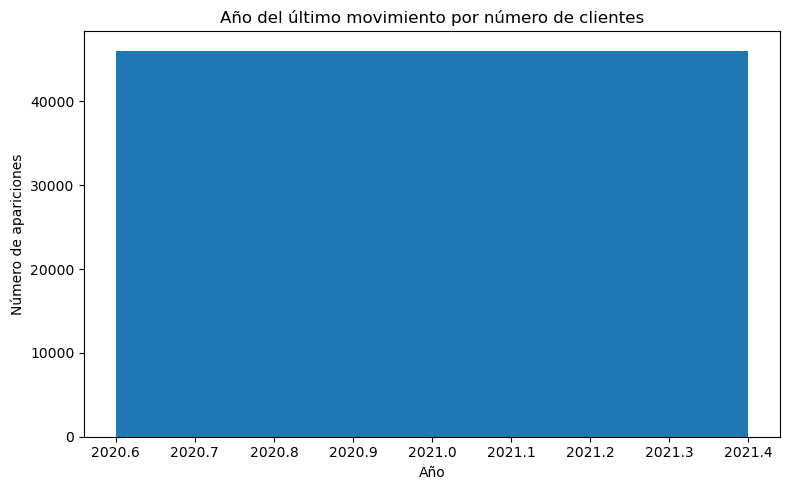

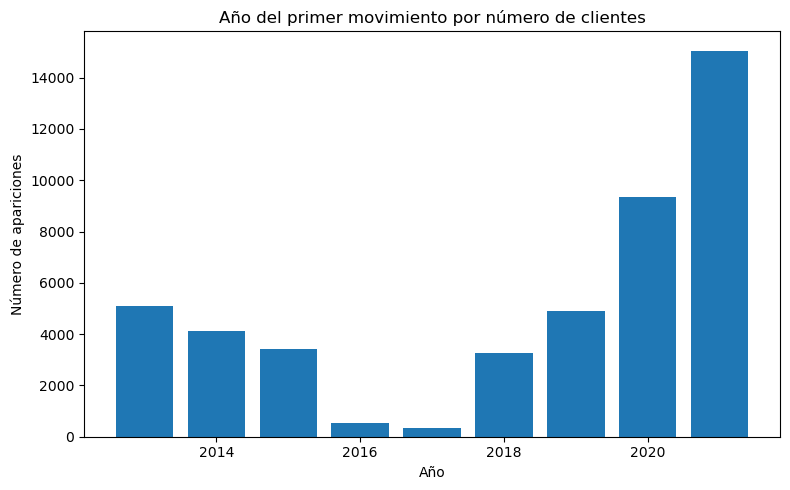

In [16]:
#Año del primer movimiento y año del último movimiento de cada cliente

w_orderClients_lastMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
df_filterd_lastMove = behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_lastMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_lastMove = df_filterd_lastMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")
pdf_lastMove = df_count_lastMove.toPandas()

w_orderClients_firstMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").asc())
df_filterd_firstMove = behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_firstMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_firstMove = df_filterd_firstMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")
pdf_firstMove = df_count_firstMove.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf_lastMove["YEAR"], pdf_lastMove["count"])   # ❗ No se especifican colores
plt.xlabel("Año")
plt.ylabel("Número de apariciones")
plt.title("Año del último movimiento por número de clientes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(pdf_firstMove["YEAR"], pdf_firstMove["count"])   # ❗ No se especifican colores
plt.xlabel("Año")
plt.ylabel("Número de apariciones")
plt.title("Año del primer movimiento por número de clientes")
plt.tight_layout()
plt.show()

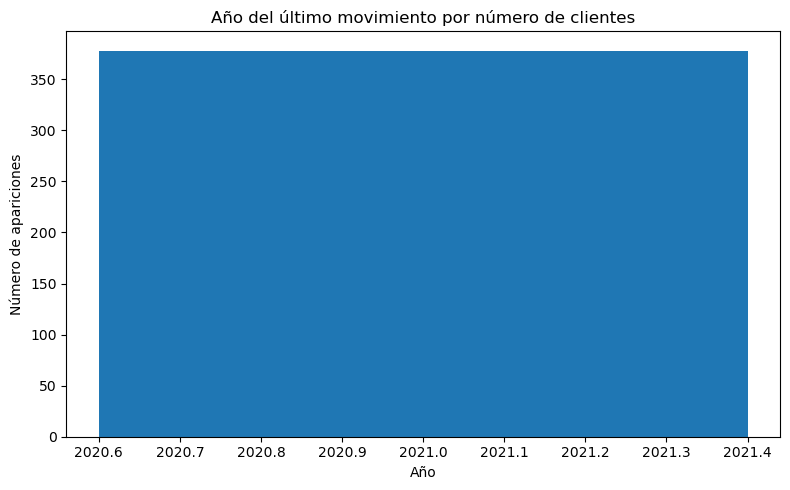

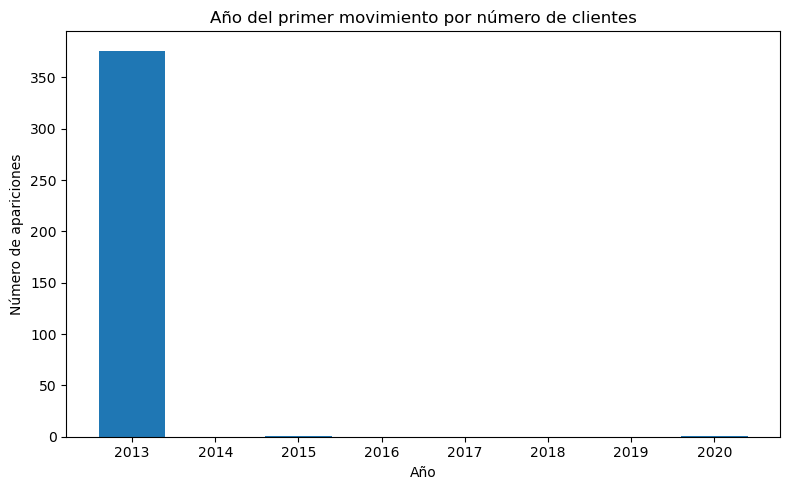

In [17]:
#Año del primer movimiento y año del último movimiento de cada cliente

w_orderClients_lastMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
df_filterd_lastMove = only_behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_lastMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_lastMove = df_filterd_lastMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")
pdf_lastMove = df_count_lastMove.toPandas()

w_orderClients_firstMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").asc())
df_filterd_firstMove = only_behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_firstMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_firstMove = df_filterd_firstMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")
pdf_firstMove = df_count_firstMove.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf_lastMove["YEAR"], pdf_lastMove["count"])   # ❗ No se especifican colores
plt.xlabel("Año")
plt.ylabel("Número de apariciones")
plt.title("Año del último movimiento por número de clientes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(pdf_firstMove["YEAR"], pdf_firstMove["count"])   # ❗ No se especifican colores
plt.xlabel("Año")
plt.ylabel("Número de apariciones")
plt.title("Año del primer movimiento por número de clientes")
plt.tight_layout()
plt.show()

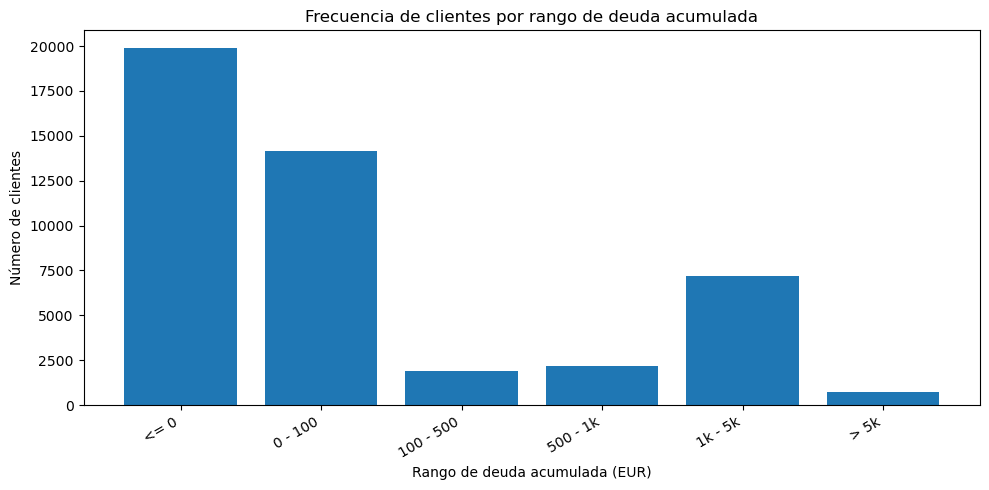

In [18]:
# 1) Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# 2) Calcular DEBT y DEBT_CUMULED
df_con_deuda = behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# 3) Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# 4) Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
#    Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# 5) Usar Bucketizer para asignar cada cliente a un bin
from pyspark.ml.feature import Bucketizer
bucketizer = Bucketizer(splits=bins, inputCol="DEBT_CUMULED", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# 6) Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

# 7) Convertir a pandas y mapear etiquetas
pdf_bins = df_bins_count.toPandas()
# Aseguramos que aparecen todos los índices (si algún bin quedó vacío puede no aparecer)
import numpy as np
all_idx = np.arange(len(labels))
pdf_full = pd.DataFrame({"debt_bin_index": all_idx})
pdf_bins = pdf_full.merge(pdf_bins, on="debt_bin_index", how="left").fillna(0)
pdf_bins["label"] = [labels[int(i)] for i in pdf_bins["debt_bin_index"]]
pdf_bins["count"] = pdf_bins["count"].astype(int)

# 8) Gráfico: barras (eje X = rango deuda, eje Y = número de clientes)
plt.figure(figsize=(10,5))
plt.bar(pdf_bins["label"], pdf_bins["count"])   # no especificamos colores
plt.xlabel("Rango de deuda acumulada (EUR)")
plt.ylabel("Número de clientes")
plt.title("Frecuencia de clientes por rango de deuda acumulada")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

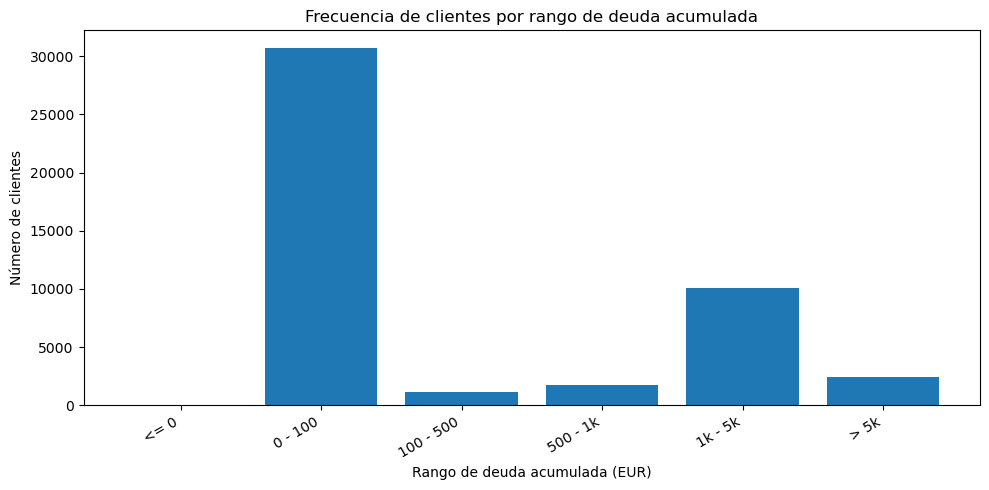

In [19]:
# 1) Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# 2) Calcular DEBT y DEBT_CUMULED
df_con_deuda = behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# 3) Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# 4) Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
#    Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# 5) Usar Bucketizer para asignar cada cliente a un bin
from pyspark.ml.feature import Bucketizer
bucketizer = Bucketizer(splits=bins, inputCol="CREDICT_CARD_BALANCE", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# 6) Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

# 7) Convertir a pandas y mapear etiquetas
pdf_bins = df_bins_count.toPandas()
# Aseguramos que aparecen todos los índices (si algún bin quedó vacío puede no aparecer)
import numpy as np
all_idx = np.arange(len(labels))
pdf_full = pd.DataFrame({"debt_bin_index": all_idx})
pdf_bins = pdf_full.merge(pdf_bins, on="debt_bin_index", how="left").fillna(0)
pdf_bins["label"] = [labels[int(i)] for i in pdf_bins["debt_bin_index"]]
pdf_bins["count"] = pdf_bins["count"].astype(int)

# 8) Gráfico: barras (eje X = rango deuda, eje Y = número de clientes)
plt.figure(figsize=(10,5))
plt.bar(pdf_bins["label"], pdf_bins["count"])   # no especificamos colores
plt.xlabel("Rango de deuda acumulada (EUR)")
plt.ylabel("Número de clientes")
plt.title("Frecuencia de clientes por rango de deuda acumulada")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

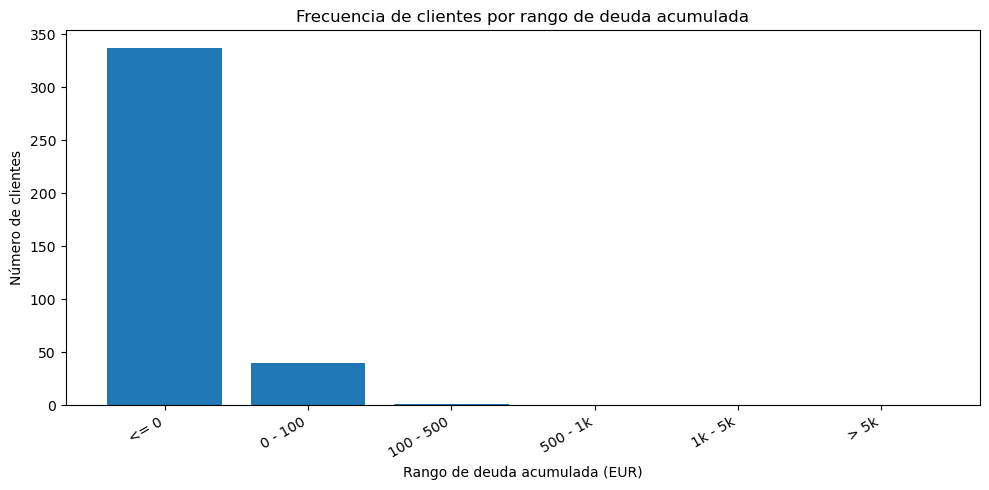

In [20]:
# 1) Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# 2) Calcular DEBT y DEBT_CUMULED
df_con_deuda = only_behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# 3) Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# 4) Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
#    Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# 5) Usar Bucketizer para asignar cada cliente a un bin
from pyspark.ml.feature import Bucketizer
bucketizer = Bucketizer(splits=bins, inputCol="DEBT_CUMULED", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# 6) Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

# 7) Convertir a pandas y mapear etiquetas
pdf_bins = df_bins_count.toPandas()
# Aseguramos que aparecen todos los índices (si algún bin quedó vacío puede no aparecer)
import numpy as np
all_idx = np.arange(len(labels))
pdf_full = pd.DataFrame({"debt_bin_index": all_idx})
pdf_bins = pdf_full.merge(pdf_bins, on="debt_bin_index", how="left").fillna(0)
pdf_bins["label"] = [labels[int(i)] for i in pdf_bins["debt_bin_index"]]
pdf_bins["count"] = pdf_bins["count"].astype(int)

# 8) Gráfico: barras (eje X = rango deuda, eje Y = número de clientes)
plt.figure(figsize=(10,5))
plt.bar(pdf_bins["label"], pdf_bins["count"])   # no especificamos colores
plt.xlabel("Rango de deuda acumulada (EUR)")
plt.ylabel("Número de clientes")
plt.title("Frecuencia de clientes por rango de deuda acumulada")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

+------------+------------+-------------------+---------------------+---------------------+-----------+
|CLIENT_ID   |TOTAL_INCOME|DEBT_CUMULED       |NET_INCOME_AFTER_DEBT|DEBT_TO_INCOME       |RISK_BUCKET|
+------------+------------+-------------------+---------------------+---------------------+-----------+
|ES182100023A|1080.0      |0.0                |1080.0               |0.0                  |LOW        |
|ES182100162C|1350.0      |0.0                |1350.0               |0.0                  |LOW        |
|ES182100299W|1350.0      |0.0                |1350.0               |0.0                  |LOW        |
|ES182100338P|3240.0      |304.1299999999992  |2935.870000000001    |0.09386728395061704  |LOW        |
|ES182100339K|1998.0      |-5776.389999999996 |7774.389999999996    |-2.891086086086084   |LOW        |
|ES182100468L|1350.0      |-1403.53           |2753.5299999999997   |-1.0396518518518518  |LOW        |
|ES182100491G|2322.0      |350.6700000000001  |1971.33          

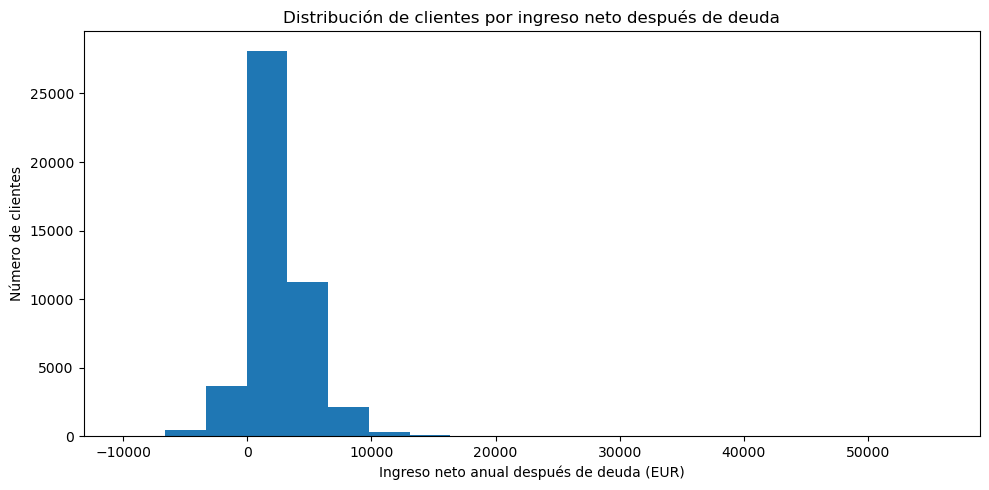

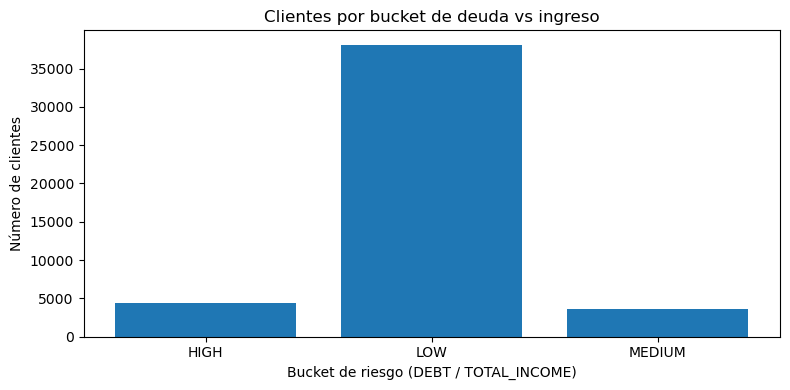

In [21]:
# --- 1) Ventanas
w_acc = Window.partitionBy("CLIENT_ID") \
              .orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w_last = Window.partitionBy("CLIENT_ID") \
               .orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# --- 2) Calcular DEBT por fila y DEBT_CUMULED
df_debt = behavioural_df.withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
            .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w_acc))

# --- 3) Obtener el registro más reciente por cliente (para tener la deuda acumulada "actual")
df_latest = df_debt.withColumn("row_num", F.row_number().over(w_last)) \
                   .filter(F.col("row_num") == 1) \
                   .drop("row_num")

# --- 4) Obtener TOTAL_INCOME por CLIENT_ID
# Opción A: si TOTAL_INCOME ya está en behavioural_df (por ejemplo repetido en cada fila)
# usamos max (o avg) para extraer el valor por cliente:
# Si tienes un DataFrame aparte con TOTAL_INCOME, coméntalo:
income_df = clientes_df.select("CLIENT_ID", "TOTAL_INCOME")

# --- 5) Unir deuda actual con ingresos
df_join = df_latest.join(income_df, on="CLIENT_ID", how="left")

# --- 6) Calcular métricas: neto, ratio y categoría (evitando división por cero / nulos)
df_result = df_join.withColumn(
    "NET_INCOME_AFTER_DEBT",
    F.col("TOTAL_INCOME") - F.col("DEBT_CUMULED")
).withColumn(
    "DEBT_TO_INCOME",
    F.when(
        (F.col("TOTAL_INCOME").isNull()) | (F.col("TOTAL_INCOME") == 0),
        None
    ).otherwise(F.col("DEBT_CUMULED") / F.col("TOTAL_INCOME"))
).withColumn(
    "RISK_BUCKET",
    F.when(F.col("DEBT_TO_INCOME").isNull(), "UNKNOWN")
     .when(F.col("DEBT_TO_INCOME") <= 0.5, "LOW")
     .when((F.col("DEBT_TO_INCOME") > 0.5) & (F.col("DEBT_TO_INCOME") <= 1.0), "MEDIUM")
     .when(F.col("DEBT_TO_INCOME") > 1.0, "HIGH")
     .otherwise("UNKNOWN")
)

# Mostrar ejemplo
df_result.select("CLIENT_ID", "TOTAL_INCOME", "DEBT_CUMULED", "NET_INCOME_AFTER_DEBT",
                 "DEBT_TO_INCOME", "RISK_BUCKET").show(20, False)

# --- 7) Agregados útiles: conteo por bucket
df_buckets = df_result.groupBy("RISK_BUCKET").count().orderBy("RISK_BUCKET")
df_buckets.show()

# --- 8) Convertir a pandas para graficar la distribución de NET_INCOME_AFTER_DEBT (histograma por rangos)
pdf = df_result.select("CLIENT_ID", "NET_INCOME_AFTER_DEBT").toPandas()

# Si hay NaNs, puedes limpiarlos o imputarlos; aquí los quitamos para el histograma:
pdf_plot = pdf.dropna(subset=["NET_INCOME_AFTER_DEBT"])

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf_plot["NET_INCOME_AFTER_DEBT"], bins=20)   # no se especifican colores
plt.xlabel("Ingreso neto anual después de deuda (EUR)")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por ingreso neto después de deuda")
plt.tight_layout()
plt.show()

# --- 9) También: gráfico de barras del RISK_BUCKET
pdf_buckets = df_buckets.toPandas()
plt.figure(figsize=(8,4))
plt.bar(pdf_buckets["RISK_BUCKET"], pdf_buckets["count"])
plt.xlabel("Bucket de riesgo (DEBT / TOTAL_INCOME)")
plt.ylabel("Número de clientes")
plt.title("Clientes por bucket de deuda vs ingreso")
plt.tight_layout()
plt.show()

+------------+------------+-------------------+---------------------+----------------------+-----------+
|CLIENT_ID   |TOTAL_INCOME|DEBT_CUMULED       |NET_INCOME_AFTER_DEBT|DEBT_TO_INCOME        |RISK_BUCKET|
+------------+------------+-------------------+---------------------+----------------------+-----------+
|ES182102540U|1350.0      |-1724.5500000000004|3074.55              |-1.2774444444444448   |LOW        |
|ES182103964A|1458.0      |-725.9700000000004 |2183.9700000000003   |-0.49792181069958874  |LOW        |
|ES182105846C|2700.0      |0.0                |2700.0               |0.0                   |LOW        |
|ES182106369W|1080.0      |-1333.9400000000044|2413.940000000004    |-1.2351296296296337   |LOW        |
|ES182106446W|2700.0      |-886.9899999999989 |3586.989999999999    |-0.32851481481481437  |LOW        |
|ES182107241R|972.0       |-0.11              |972.11               |-1.1316872427983539E-4|LOW        |
|ES182107821P|1188.0      |-3372.4999999999995|4560.5  

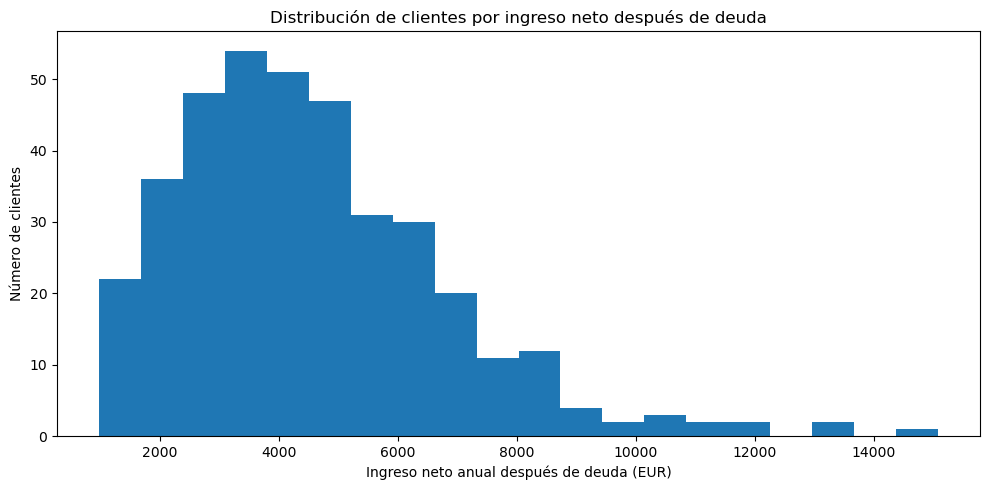

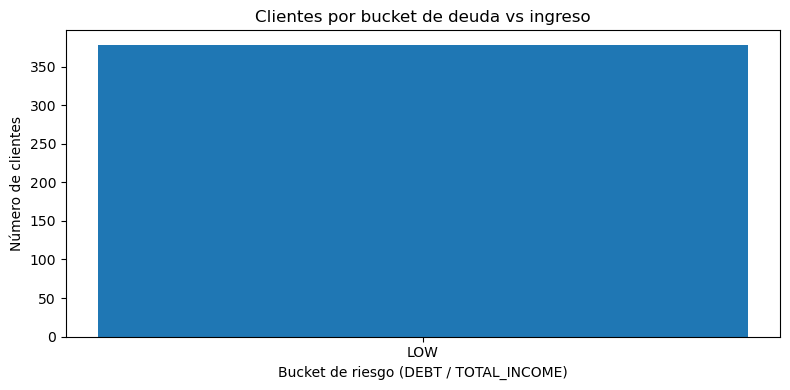

In [22]:
# --- 1) Ventanas
w_acc = Window.partitionBy("CLIENT_ID") \
              .orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w_last = Window.partitionBy("CLIENT_ID") \
               .orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# --- 2) Calcular DEBT por fila y DEBT_CUMULED
df_debt = only_behavioural_df.withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
            .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w_acc))

# --- 3) Obtener el registro más reciente por cliente (para tener la deuda acumulada "actual")
df_latest = df_debt.withColumn("row_num", F.row_number().over(w_last)) \
                   .filter(F.col("row_num") == 1) \
                   .drop("row_num")

# --- 4) Obtener TOTAL_INCOME por CLIENT_ID
# Opción A: si TOTAL_INCOME ya está en behavioural_df (por ejemplo repetido en cada fila)
# usamos max (o avg) para extraer el valor por cliente:
# Si tienes un DataFrame aparte con TOTAL_INCOME, coméntalo:
income_df = clientes_df.select("CLIENT_ID", "TOTAL_INCOME")

# --- 5) Unir deuda actual con ingresos
df_join = df_latest.join(income_df, on="CLIENT_ID", how="left")

# --- 6) Calcular métricas: neto, ratio y categoría (evitando división por cero / nulos)
df_result = df_join.withColumn(
    "NET_INCOME_AFTER_DEBT",
    F.col("TOTAL_INCOME") - F.col("DEBT_CUMULED")
).withColumn(
    "DEBT_TO_INCOME",
    F.when(
        (F.col("TOTAL_INCOME").isNull()) | (F.col("TOTAL_INCOME") == 0),
        None
    ).otherwise(F.col("DEBT_CUMULED") / F.col("TOTAL_INCOME"))
).withColumn(
    "RISK_BUCKET",
    F.when(F.col("DEBT_TO_INCOME").isNull(), "UNKNOWN")
     .when(F.col("DEBT_TO_INCOME") <= 0.5, "LOW")
     .when((F.col("DEBT_TO_INCOME") > 0.5) & (F.col("DEBT_TO_INCOME") <= 1.0), "MEDIUM")
     .when(F.col("DEBT_TO_INCOME") > 1.0, "HIGH")
     .otherwise("UNKNOWN")
)

# Mostrar ejemplo
df_result.select("CLIENT_ID", "TOTAL_INCOME", "DEBT_CUMULED", "NET_INCOME_AFTER_DEBT",
                 "DEBT_TO_INCOME", "RISK_BUCKET").show(20, False)

# --- 7) Agregados útiles: conteo por bucket
df_buckets = df_result.groupBy("RISK_BUCKET").count().orderBy("RISK_BUCKET")
df_buckets.show()

# --- 8) Convertir a pandas para graficar la distribución de NET_INCOME_AFTER_DEBT (histograma por rangos)
pdf = df_result.select("CLIENT_ID", "NET_INCOME_AFTER_DEBT").toPandas()

# Si hay NaNs, puedes limpiarlos o imputarlos; aquí los quitamos para el histograma:
pdf_plot = pdf.dropna(subset=["NET_INCOME_AFTER_DEBT"])

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf_plot["NET_INCOME_AFTER_DEBT"], bins=20)   # no se especifican colores
plt.xlabel("Ingreso neto anual después de deuda (EUR)")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por ingreso neto después de deuda")
plt.tight_layout()
plt.show()

# --- 9) También: gráfico de barras del RISK_BUCKET
pdf_buckets = df_buckets.toPandas()
plt.figure(figsize=(8,4))
plt.bar(pdf_buckets["RISK_BUCKET"], pdf_buckets["count"])
plt.xlabel("Bucket de riesgo (DEBT / TOTAL_INCOME)")
plt.ylabel("Número de clientes")
plt.title("Clientes por bucket de deuda vs ingreso")
plt.tight_layout()
plt.show()

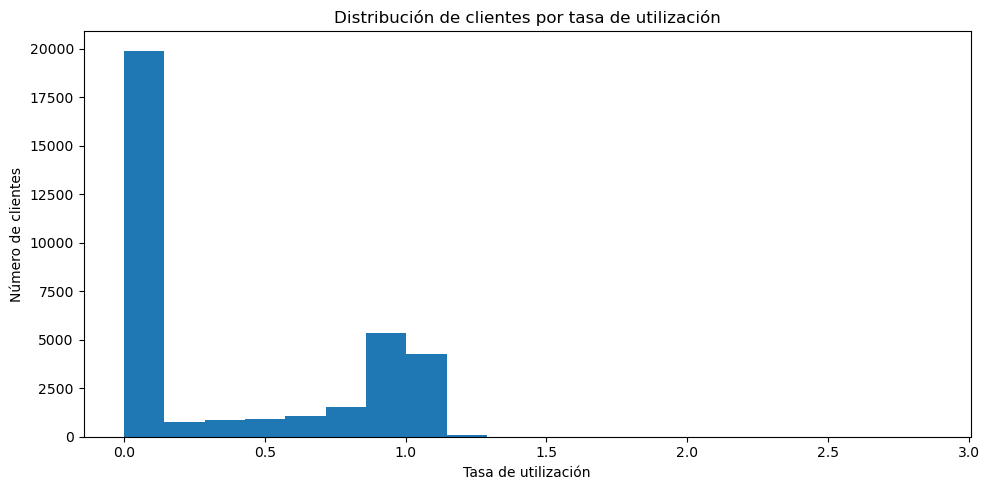

In [23]:
# Cálculo de tasa de utilización
df_util = (
    behavioural_df
    .withColumn("UTILIZATION", F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
)

w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

pdf = df_util_latest.select("CLIENT_ID", "UTILIZATION").toPandas()

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf["UTILIZATION"], bins=20)   # no se especifican colores
plt.xlabel("Tasa de utilización")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por tasa de utilización")
plt.tight_layout()
plt.show()

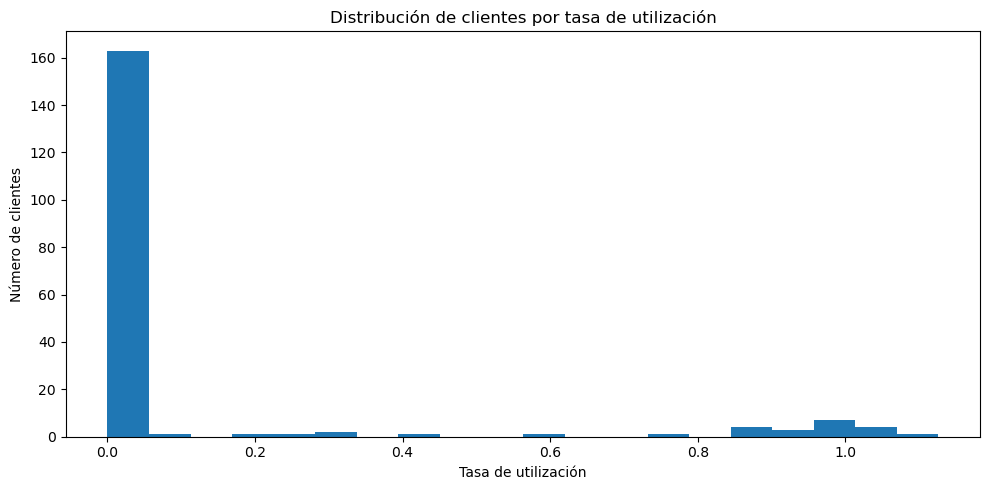

In [24]:
# Cálculo de tasa de utilización
df_util = (
    only_behavioural_df
    .withColumn("UTILIZATION", F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
)

w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

pdf = df_util_latest.select("CLIENT_ID", "UTILIZATION").toPandas()

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf["UTILIZATION"], bins=20)   # no se especifican colores
plt.xlabel("Tasa de utilización")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por tasa de utilización")
plt.tight_layout()
plt.show()

+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+--------+------+-------------------+------------+--------------------+
|   CLIENT_ID|       CONTRACT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|CURRENCY|  DEBT|       DEBT_CUMULED|TOTAL_INCOME|         UTILIZATION|
+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+--------+------+-------------------+------------+--------------------+
|ES182190549V|ES182

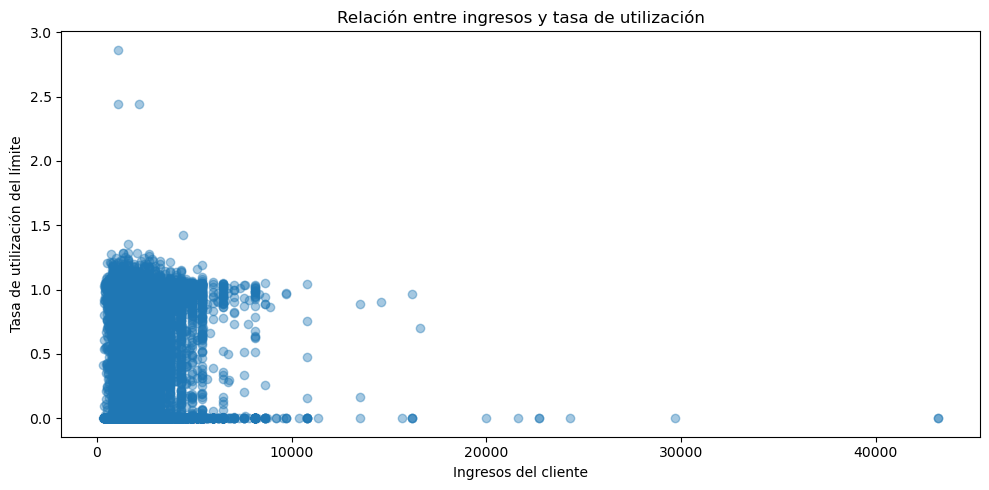

In [25]:
# Ventana para acumular deuda por cliente a lo largo del tiempo
w = Window.partitionBy("CLIENT_ID") \
          .orderBy(F.col("DATE").asc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_deuda = behavioural_df \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))


# =============================================
# 2. Extraer el registro más reciente por cliente
# =============================================

w_desc = Window.partitionBy("CLIENT_ID") \
               .orderBy(F.col("DATE").desc())

df_ultima_deuda = df_deuda \
    .withColumn("row_num", F.row_number().over(w_desc)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")


# ===========================
# 3. Unir con ingresos
# ===========================

income_df = clientes_df.select("CLIENT_ID", "TOTAL_INCOME")
df_merged = df_ultima_deuda.join(income_df, on="CLIENT_ID", how="left")


# =============================================
# 4. Calcular tasa de utilización del límite
# =============================================

df_merged = df_merged.withColumn("UTILIZATION", F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))

df_merged.orderBy(F.col("TOTAL_INCOME")).show()

# ===========================
# 5. Convertir a pandas
# ===========================

pdf = df_merged.select("TOTAL_INCOME", "UTILIZATION") \
               .toPandas()


# ===========================
# 6. Graficar
# ===========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(pdf["TOTAL_INCOME"], pdf["UTILIZATION"], alpha=0.4)

plt.xlabel("Ingresos del cliente")
plt.ylabel("Tasa de utilización del límite")
plt.title("Relación entre ingresos y tasa de utilización")

plt.tight_layout()
plt.show()

+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+------+-------------------+------------+------------------+
|   CLIENT_ID|       CONTRACT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|  DEBT|       DEBT_CUMULED|TOTAL_INCOME|       UTILIZATION|
+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+------+-------------------+------------+------------------+
|ES182151103T|ES1821432114a00XXX|2021-10-30|        

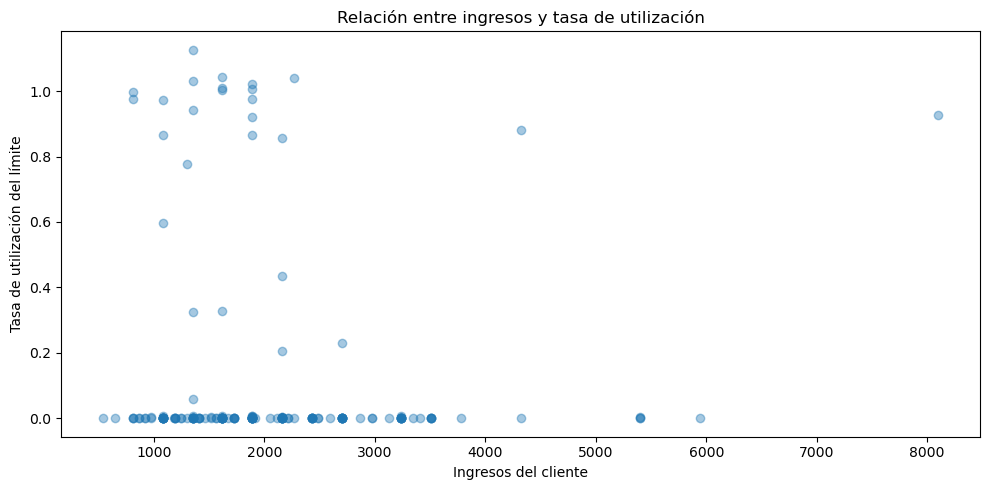

In [26]:
# Ventana para acumular deuda por cliente a lo largo del tiempo
w = Window.partitionBy("CLIENT_ID") \
          .orderBy(F.col("DATE").asc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_deuda = only_behavioural_df \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))


# =============================================
# 2. Extraer el registro más reciente por cliente
# =============================================

w_desc = Window.partitionBy("CLIENT_ID") \
               .orderBy(F.col("DATE").desc())

df_ultima_deuda = df_deuda \
    .withColumn("row_num", F.row_number().over(w_desc)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")


# ===========================
# 3. Unir con ingresos
# ===========================

income_df = clientes_df.select("CLIENT_ID", "TOTAL_INCOME")
df_merged = df_ultima_deuda.join(income_df, on="CLIENT_ID", how="left")


# =============================================
# 4. Calcular tasa de utilización del límite
# =============================================

df_merged = df_merged.withColumn("UTILIZATION", F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))

df_merged.orderBy(F.col("TOTAL_INCOME")).show()

# ===========================
# 5. Convertir a pandas
# ===========================

pdf = df_merged.select("TOTAL_INCOME", "UTILIZATION") \
               .toPandas()


# ===========================
# 6. Graficar
# ===========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(pdf["TOTAL_INCOME"], pdf["UTILIZATION"], alpha=0.4)

plt.xlabel("Ingresos del cliente")
plt.ylabel("Tasa de utilización del límite")
plt.title("Relación entre ingresos y tasa de utilización")

plt.tight_layout()
plt.show()

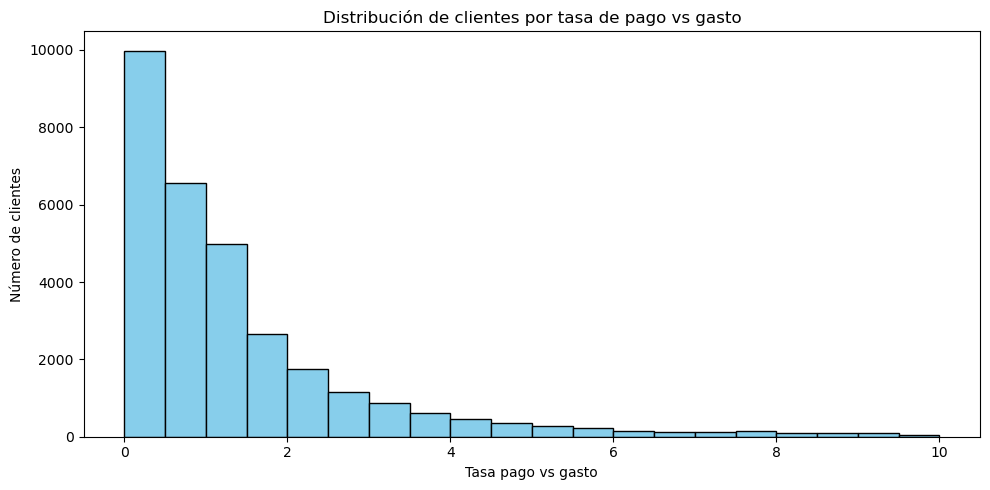

count    31639.000000
mean         3.973530
std        120.778540
min         -4.136757
25%          0.346419
50%          0.934444
75%          1.910342
max      13735.346846
Name: PAY/DRAW_avg, dtype: float64

In [27]:
# Cálculo de tasa de utilización
w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
w1 = Window.partitionBy("CLIENT_ID") \
          .orderBy(F.col("DATE").asc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_util = behavioural_df \
    .withColumn("PAY/DRAW", F.when(F.col("CREDIT_CARD_DRAWINGS") != 0,
                                F.col("CREDIT_CARD_PAYMENT") / F.col("CREDIT_CARD_DRAWINGS"))
                           .otherwise(None)) \
    .withColumn("PAY/DRAW_avg", F.avg("PAY/DRAW").over(w1))

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

pdf = df_util_latest.select("CLIENT_ID", "PAY/DRAW_avg").toPandas()

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf["PAY/DRAW_avg"], bins=20, range=(0,10), color='skyblue', edgecolor='black')
plt.xlabel("Tasa pago vs gasto")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por tasa de pago vs gasto")
plt.tight_layout()
plt.show()


pdf["PAY/DRAW_avg"].describe()

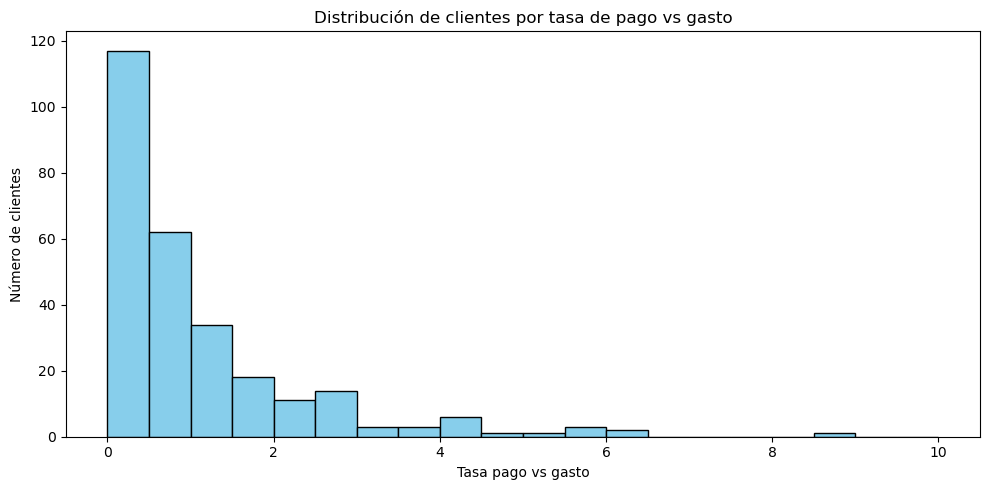

count    280.000000
mean       1.469044
std        4.156279
min        0.000000
25%        0.239871
50%        0.634079
75%        1.416191
max       60.600000
Name: PAY/DRAW_avg, dtype: float64

In [28]:
# Cálculo de tasa de utilización
w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
w1 = Window.partitionBy("CLIENT_ID") \
          .orderBy(F.col("DATE").asc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_util = only_behavioural_df \
    .withColumn("PAY/DRAW", F.when(F.col("CREDIT_CARD_DRAWINGS") != 0,
                                F.col("CREDIT_CARD_PAYMENT") / F.col("CREDIT_CARD_DRAWINGS"))
                           .otherwise(None)) \
    .withColumn("PAY/DRAW_avg", F.avg("PAY/DRAW").over(w1))

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

pdf = df_util_latest.select("CLIENT_ID", "PAY/DRAW_avg").toPandas()

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf["PAY/DRAW_avg"], bins=20, range=(0,10), color='skyblue', edgecolor='black')
plt.xlabel("Tasa pago vs gasto")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por tasa de pago vs gasto")
plt.tight_layout()
plt.show()


pdf["PAY/DRAW_avg"].describe()

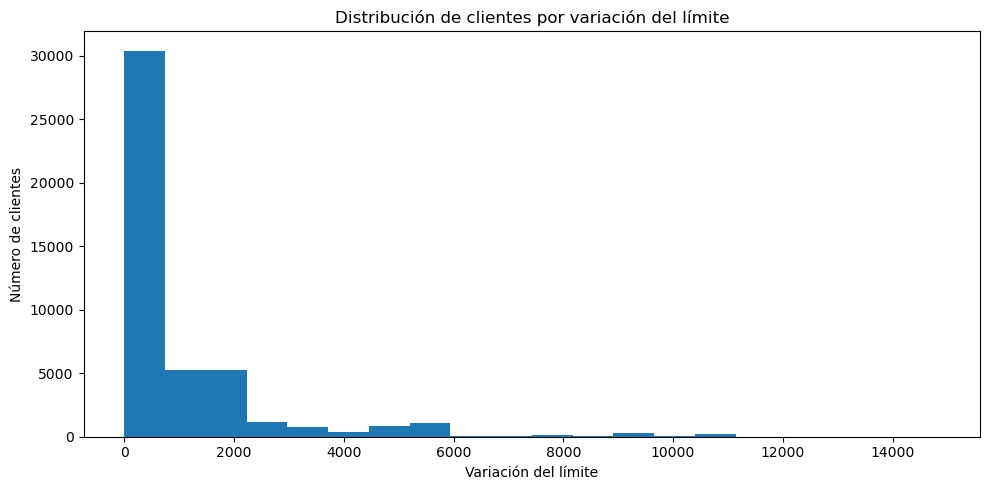

In [29]:
# -----------------------------------------
# 1. Límite máximo por cliente
# -----------------------------------------
df_max_limit = behavioural_df.groupBy("CLIENT_ID") \
    .agg(F.max("CREDIT_CARD_LIMIT").alias("MAX_LIMIT"))

# -----------------------------------------
# 2. Límite más reciente por cliente
# -----------------------------------------
w_recent = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())

df_recent_limit = (
    behavioural_df
        .withColumn("rn", F.row_number().over(w_recent))
        .filter(F.col("rn") == 1)
        .select("CLIENT_ID", "CREDIT_CARD_LIMIT")
        .withColumnRenamed("CREDIT_CARD_LIMIT", "RECENT_LIMIT")
)

# -----------------------------------------
# 3. Cálculo de la variación del límite
# -----------------------------------------
df_limit_variation = (
    df_max_limit
        .join(df_recent_limit, on="CLIENT_ID")
        .withColumn("LIMIT_VARIATION", F.col("MAX_LIMIT") - F.col("RECENT_LIMIT"))
)

# -----------------------------------------
# 5. Convertir a Pandas para graficar
# -----------------------------------------
pdf = df_limit_variation.select("CLIENT_ID", "LIMIT_VARIATION").toPandas()

# -----------------------------------------
# 6. Gráfico final
# -----------------------------------------
plt.figure(figsize=(10,5))
plt.hist(pdf["LIMIT_VARIATION"], bins=20)   # no se especifican colores
plt.xlabel("Variación del límite")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por variación del límite")
plt.tight_layout()
plt.show()

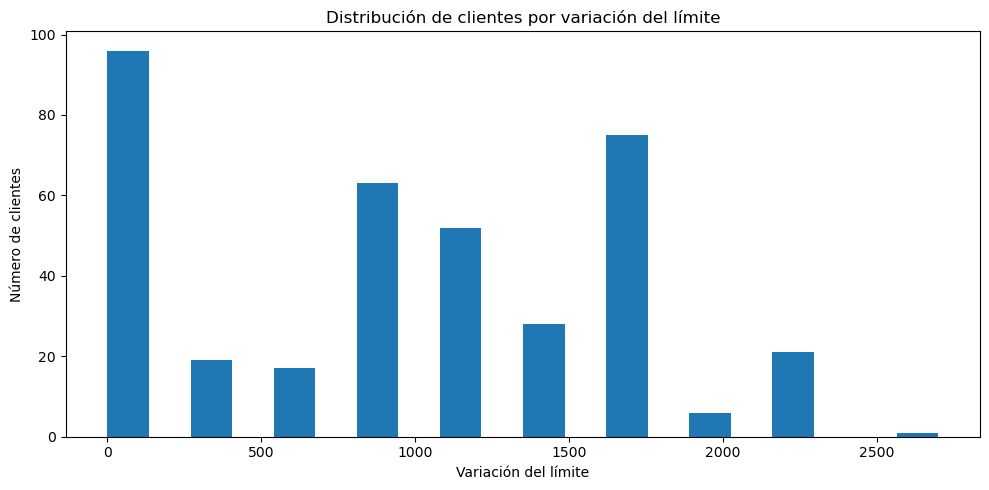

In [30]:
# -----------------------------------------
# 1. Límite máximo por cliente
# -----------------------------------------
df_max_limit = only_behavioural_df.groupBy("CLIENT_ID") \
    .agg(F.max("CREDIT_CARD_LIMIT").alias("MAX_LIMIT"))

# -----------------------------------------
# 2. Límite más reciente por cliente
# -----------------------------------------
w_recent = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())

df_recent_limit = (
    only_behavioural_df
        .withColumn("rn", F.row_number().over(w_recent))
        .filter(F.col("rn") == 1)
        .select("CLIENT_ID", "CREDIT_CARD_LIMIT")
        .withColumnRenamed("CREDIT_CARD_LIMIT", "RECENT_LIMIT")
)

# -----------------------------------------
# 3. Cálculo de la variación del límite
# -----------------------------------------
df_limit_variation = (
    df_max_limit
        .join(df_recent_limit, on="CLIENT_ID")
        .withColumn("LIMIT_VARIATION", F.col("MAX_LIMIT") - F.col("RECENT_LIMIT"))
)

# -----------------------------------------
# 5. Convertir a Pandas para graficar
# -----------------------------------------
pdf = df_limit_variation.select("CLIENT_ID", "LIMIT_VARIATION").toPandas()

# -----------------------------------------
# 6. Gráfico final
# -----------------------------------------
plt.figure(figsize=(10,5))
plt.hist(pdf["LIMIT_VARIATION"], bins=20)   # no se especifican colores
plt.xlabel("Variación del límite")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por variación del límite")
plt.tight_layout()
plt.show()

# ÁNGELA

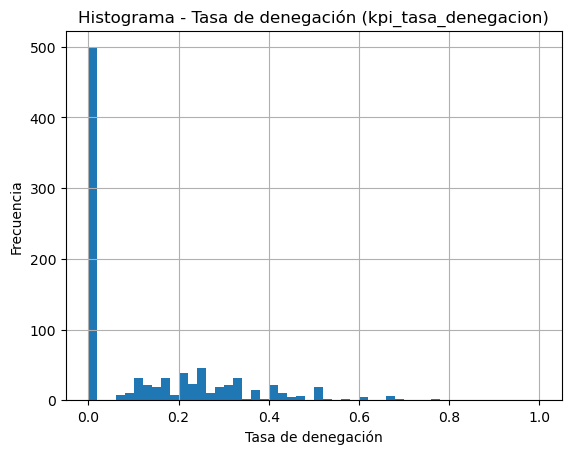

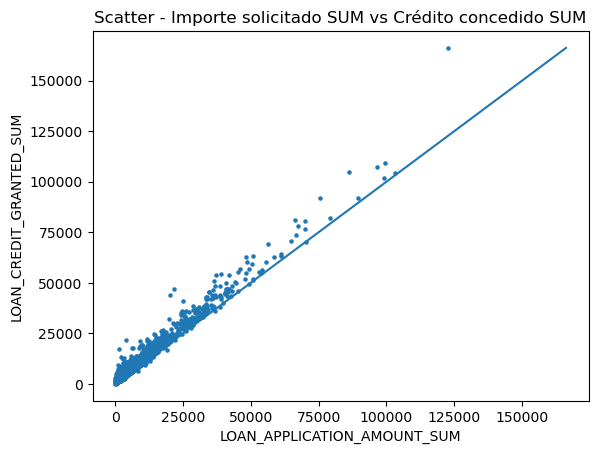

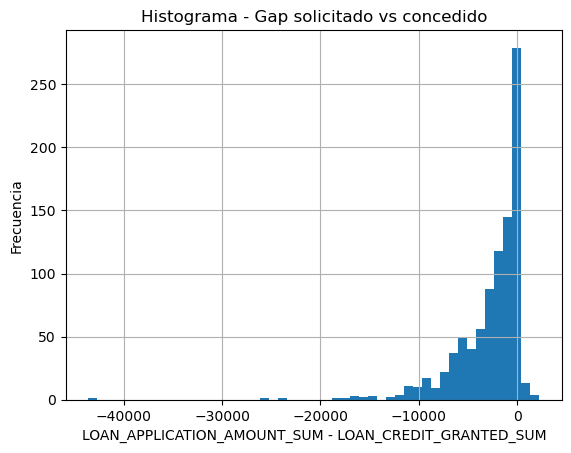

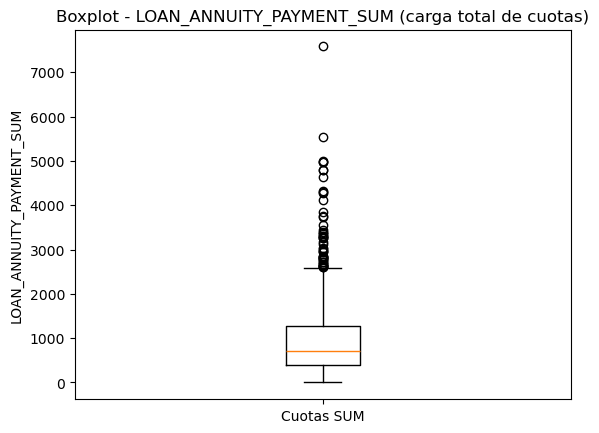

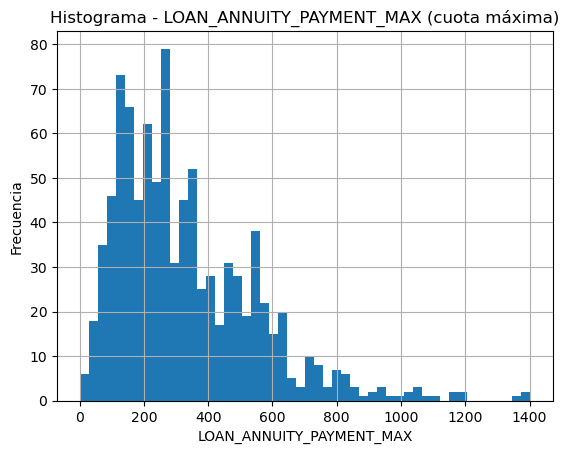

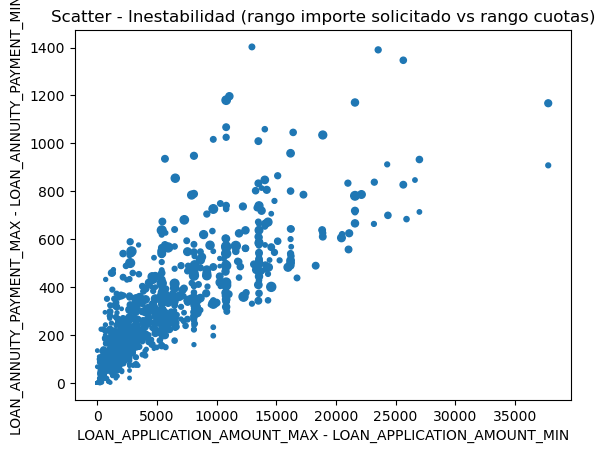

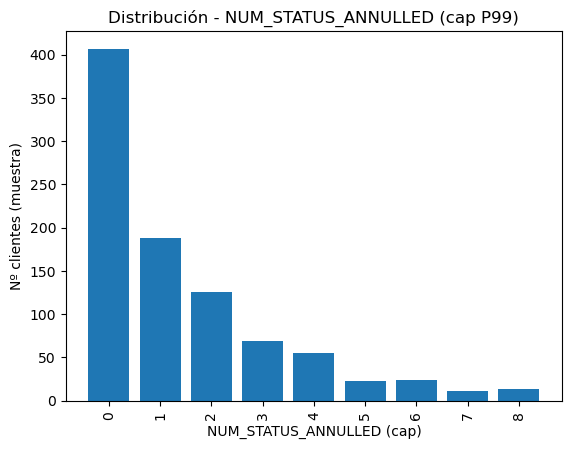

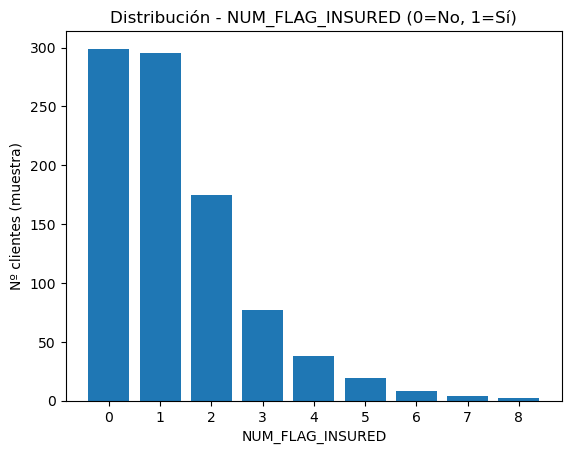

In [31]:
from pyspark.sql import functions as F

# =========================
# 1) KPIs (sin cambiar datos base)
# =========================
df_kpi = (
    comunes_df
    .withColumn(
        "kpi_tasa_denegacion",
        F.when(F.col("NUM_PREVIOUS_LOAN_APP") > 0,
               F.col("NUM_STATUS_DENIED") / F.col("NUM_PREVIOUS_LOAN_APP")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_ratio_concesion",
        F.when(F.col("LOAN_APPLICATION_AMOUNT_SUM") > 0,
               F.col("LOAN_CREDIT_GRANTED_SUM") / F.col("LOAN_APPLICATION_AMOUNT_SUM")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_gap_solicitado_concedido",
        F.col("LOAN_APPLICATION_AMOUNT_SUM") - F.col("LOAN_CREDIT_GRANTED_SUM")
    )
    .withColumn(
        "kpi_rango_importe_solicitado",
        F.col("LOAN_APPLICATION_AMOUNT_MAX") - F.col("LOAN_APPLICATION_AMOUNT_MIN")
    )
    .withColumn(
        "kpi_rango_cuotas",
        F.col("LOAN_ANNUITY_PAYMENT_MAX") - F.col("LOAN_ANNUITY_PAYMENT_MIN")
    )
    .withColumn(
        "kpi_rango_tipo_variable",
        F.col("LOAN_VARIABLE_RATE_MAX") - F.col("LOAN_VARIABLE_RATE_MIN")
    )
    .withColumn(
        "kpi_ratio_anulados",
        F.when(F.col("NUM_PREVIOUS_LOAN_APP") > 0,
               F.col("NUM_STATUS_ANNULLED") / F.col("NUM_PREVIOUS_LOAN_APP")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_ratio_not_used",
        F.when(F.col("NUM_PREVIOUS_LOAN_APP") > 0,
               F.col("NUM_STATUS_NOT_USED") / F.col("NUM_PREVIOUS_LOAN_APP")
        ).otherwise(F.lit(None))
    )
)

# =========================
# 2) Muestreo para plot (ajusta frac si hace falta)
# =========================
cols_plot = [
    "CLIENT_ID",
    "NUM_PREVIOUS_LOAN_APP",
    "NUM_FLAG_INSURED",
    "LOAN_APPLICATION_AMOUNT_SUM",
    "LOAN_CREDIT_GRANTED_SUM",
    "LOAN_ANNUITY_PAYMENT_SUM",
    "LOAN_ANNUITY_PAYMENT_MAX",
    "NUM_STATUS_ANNULLED",
    "NUM_STATUS_DENIED",
    "kpi_tasa_denegacion",
    "kpi_ratio_concesion",
    "kpi_gap_solicitado_concedido",
    "kpi_rango_importe_solicitado",
    "kpi_rango_cuotas",
]

# Para datasets grandes: sample + limit
df_sample = (
    df_kpi.select(*[c for c in cols_plot if c in df_kpi.columns])
    .sample(withReplacement=False, fraction=0.02, seed=42)  # 2% (ajusta)
    .limit(200_000)  # tope por seguridad
)

pdf = df_sample.toPandas()

# =========================
# 3) Plots (matplotlib, sin seaborn)
# =========================
import matplotlib.pyplot as plt

def _clean_series(s):
    return s.dropna()

# 3.1 Histograma - Tasa de denegación
plt.figure()
_clean_series(pdf["kpi_tasa_denegacion"]).hist(bins=50)
plt.title("Histograma - Tasa de denegación (kpi_tasa_denegacion)")
plt.xlabel("Tasa de denegación")
plt.ylabel("Frecuencia")
plt.show()

# 3.2 Scatter - Solicitado vs Concedido + línea y=x
plt.figure()
x = _clean_series(pdf["LOAN_APPLICATION_AMOUNT_SUM"])
y = pdf.loc[x.index, "LOAN_CREDIT_GRANTED_SUM"].dropna()
idx = y.index.intersection(x.index)
plt.scatter(pdf.loc[idx, "LOAN_APPLICATION_AMOUNT_SUM"], pdf.loc[idx, "LOAN_CREDIT_GRANTED_SUM"], s=5)

# línea y=x con el rango común (no cambia colores)
mn = min(pdf.loc[idx, "LOAN_APPLICATION_AMOUNT_SUM"].min(), pdf.loc[idx, "LOAN_CREDIT_GRANTED_SUM"].min())
mx = max(pdf.loc[idx, "LOAN_APPLICATION_AMOUNT_SUM"].max(), pdf.loc[idx, "LOAN_CREDIT_GRANTED_SUM"].max())
plt.plot([mn, mx], [mn, mx])

plt.title("Scatter - Importe solicitado SUM vs Crédito concedido SUM")
plt.xlabel("LOAN_APPLICATION_AMOUNT_SUM")
plt.ylabel("LOAN_CREDIT_GRANTED_SUM")
plt.show()

# 3.3 Histograma - Gap solicitado vs concedido
plt.figure()
_clean_series(pdf["kpi_gap_solicitado_concedido"]).hist(bins=50)
plt.title("Histograma - Gap solicitado vs concedido")
plt.xlabel("LOAN_APPLICATION_AMOUNT_SUM - LOAN_CREDIT_GRANTED_SUM")
plt.ylabel("Frecuencia")
plt.show()

# 3.4 Boxplot - Carga total de cuotas
plt.figure()
plt.boxplot(_clean_series(pdf["LOAN_ANNUITY_PAYMENT_SUM"]), vert=True, showfliers=True)
plt.title("Boxplot - LOAN_ANNUITY_PAYMENT_SUM (carga total de cuotas)")
plt.ylabel("LOAN_ANNUITY_PAYMENT_SUM")
plt.xticks([1], ["Cuotas SUM"])
plt.show()

# 3.5 Histograma - Cuota máxima
plt.figure()
_clean_series(pdf["LOAN_ANNUITY_PAYMENT_MAX"]).hist(bins=50)
plt.title("Histograma - LOAN_ANNUITY_PAYMENT_MAX (cuota máxima)")
plt.xlabel("LOAN_ANNUITY_PAYMENT_MAX")
plt.ylabel("Frecuencia")
plt.show()

# 3.6 Scatter - Inestabilidad: rango importes vs rango cuotas (tamaño por nº solicitudes si está)
plt.figure()
mask = pdf["kpi_rango_importe_solicitado"].notna() & pdf["kpi_rango_cuotas"].notna()
sizes = None
if "NUM_PREVIOUS_LOAN_APP" in pdf.columns:
    # tamaño proporcional (acotado)
    s = pdf.loc[mask, "NUM_PREVIOUS_LOAN_APP"].fillna(0)
    sizes = (s.clip(lower=0, upper=s.quantile(0.99)) + 1) * 2

plt.scatter(
    pdf.loc[mask, "kpi_rango_importe_solicitado"],
    pdf.loc[mask, "kpi_rango_cuotas"],
    s=5 if sizes is None else sizes
)
plt.title("Scatter - Inestabilidad (rango importe solicitado vs rango cuotas)")
plt.xlabel("LOAN_APPLICATION_AMOUNT_MAX - LOAN_APPLICATION_AMOUNT_MIN")
plt.ylabel("LOAN_ANNUITY_PAYMENT_MAX - LOAN_ANNUITY_PAYMENT_MIN")
plt.show()

# 3.7 Bar - Productos anulados (distribución)
plt.figure()
# Conteo por valor (si hay demasiados valores distintos, lo acotamos al percentil 99)
v = _clean_series(pdf["NUM_STATUS_ANNULLED"]).astype(int)
cap = int(v.quantile(0.99))
v2 = v.clip(upper=cap)
counts = v2.value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.title("Distribución - NUM_STATUS_ANNULLED (cap P99)")
plt.xlabel("NUM_STATUS_ANNULLED (cap)")
plt.ylabel("Nº clientes (muestra)")
plt.xticks(rotation=90)
plt.show()

# 3.8 Bar - Vinculación (NUM_FLAG_INSURED)
if "NUM_FLAG_INSURED" in pdf.columns:
    plt.figure()
    v = _clean_series(pdf["NUM_FLAG_INSURED"]).astype(int)
    counts = v.value_counts().sort_index()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distribución - NUM_FLAG_INSURED (0=No, 1=Sí)")
    plt.xlabel("NUM_FLAG_INSURED")
    plt.ylabel("Nº clientes (muestra)")
    plt.show()


1. Histograma – Tasa de denegación
Lo que se observa

Pico muy fuerte en 0

Cola larga hasta valores altos (≈0.6–1)

Consecuencia

La mayoría de los clientes comunes no experimenta denegaciones, pero existe un subconjunto relevante con tasas de denegación elevadas.

Interpretación de abandono

Clientes con tasa de denegación > 0.3 son outliers de frustración crediticia

Este grupo es altamente vulnerable al churn

📌 Indicio fuerte: la frustración no es generalizada, pero cuando aparece es intensa y concentrada.

2. Scatter – Importe solicitado vs crédito concedido
Lo que se observa

Fuerte correlación (línea casi y = x)

Muchos puntos sistemáticamente por debajo de la diagonal

Algunos casos extremos de alta solicitud y menor concesión

Consecuencia

Aunque el banco concede crédito de forma proporcional, existe un patrón claro de infrafinanciación para un subconjunto de clientes.

Interpretación de abandono

Clientes lejos de la diagonal (solicitan mucho más de lo que reciben) son:

Clientes insatisfechos

Con mayor probabilidad de buscar financiación externa

📌 Indicio muy fuerte: el gap persistente es uno de los mejores predictores de abandono.

3. Histograma – Gap solicitado vs concedido

(valores negativos = se concede menos de lo solicitado)

Lo que se observa

Distribución claramente sesgada a valores negativos

Cola larga de gaps muy grandes

Consecuencia

El banco concede sistemáticamente menos crédito del solicitado en muchos casos, y para algunos clientes la diferencia es muy elevada.

Interpretación de abandono

Gaps grandes y repetidos ⇒ percepción de rechazo

Especialmente crítico cuando se combina con:

muchas solicitudes

denegaciones previas

📌 Indicio crítico cuando el gap es estructural, no puntual.

4. Boxplot – LOAN_ANNUITY_PAYMENT_SUM (carga total de cuotas)
Lo que se observa

Mediana relativamente baja

Muchísimos outliers altos

Distribución muy asimétrica

Consecuencia

Existe un grupo reducido de clientes con una carga financiera significativamente superior al resto.

Interpretación de abandono

Estos clientes:

tienen estrés financiero

son sensibles a condiciones (intereses, refinanciación)

pueden irse si no se les ofrece alivio

📌 Indicio medio–alto: no todos abandonan, pero es un perfil inestable.

5. Histograma – LOAN_ANNUITY_PAYMENT_MAX
Lo que se observa

Distribución sesgada a la derecha

Cuotas máximas muy altas para pocos clientes

Consecuencia

Algunos clientes afrontan picos de cuota muy elevados, aunque su media no sea extrema.

Interpretación de abandono

Picos de cuota generan:

estrés puntual

mala experiencia

cancelaciones posteriores

📌 Indicio complementario: refuerza el estrés financiero observado antes.

6. Scatter – Inestabilidad (rango importes vs rango cuotas)
Lo que se observa

Relación positiva clara

Nube muy dispersa

Algunos clientes extremadamente inestables

Consecuencia

Existe un segmento de clientes con comportamiento financiero altamente volátil.

Interpretación de abandono

Inestabilidad implica:

necesidades cambiantes

menor fidelidad

mayor probabilidad de cambiar de banco

📌 Indicio medio, pero muy relevante cuando se combina con frustración crediticia.

7. Distribución – NUM_STATUS_ANNULLED
Lo que se observa

Gran masa en 0

Descenso progresivo, pero con clientes que acumulan muchas anulaciones

Consecuencia

La mayoría no cancela productos, pero los que lo hacen suelen hacerlo repetidamente.

Interpretación de abandono

Cancelar productos es una señal clara de desvinculación

Repetición ⇒ pérdida de confianza

📌 Indicio muy fuerte: la desvinculación precede al abandono.

8. Distribución – NUM_FLAG_INSURED
Lo que se observa

Muchos clientes con valores bajos

Muy pocos con alta vinculación

Consecuencia

La vinculación con productos adicionales es baja para la mayoría de clientes.

Interpretación de abandono

Baja vinculación ⇒ bajo coste de salida

Clientes sin productos asociados se van más fácilmente

📌 Indicio estructural de churn.

CONCLUSIÓN GLOBAL (de estas gráficas)

Puedes afirmar con seguridad:

El abandono potencial no es masivo ni aleatorio, sino que se concentra en clientes con frustración crediticia persistente, infrafinanciación, alta carga o inestabilidad financiera y baja vinculación con productos del banco.

Jerarquía de riesgo (según lo observado)

Frustración crediticia (denegaciones + gap) 🔴

Desvinculación (anulaciones, baja vinculación) 🔴

Estrés financiero 🟠

Inestabilidad 🟠

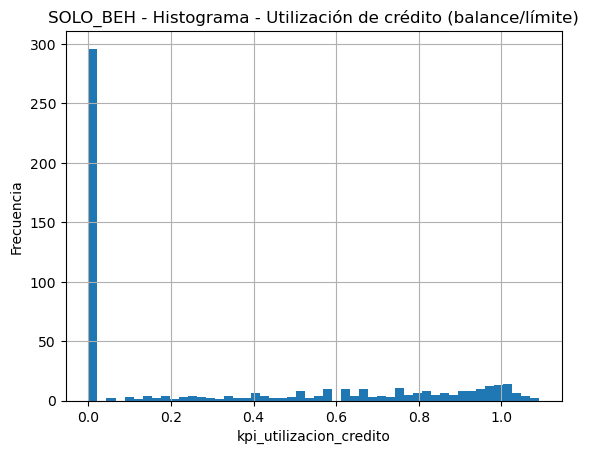

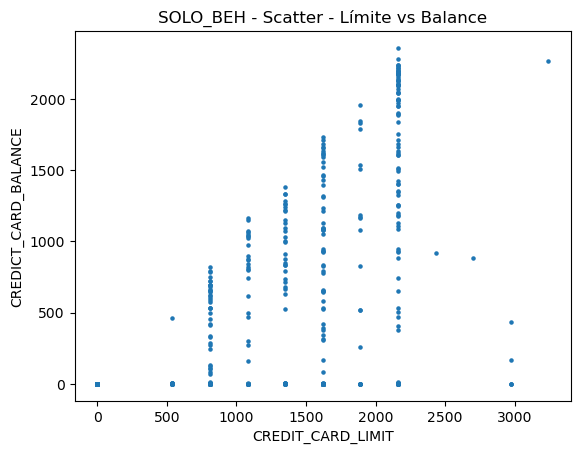

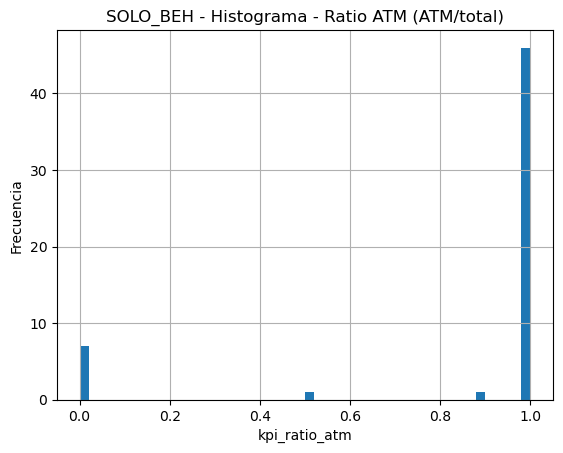

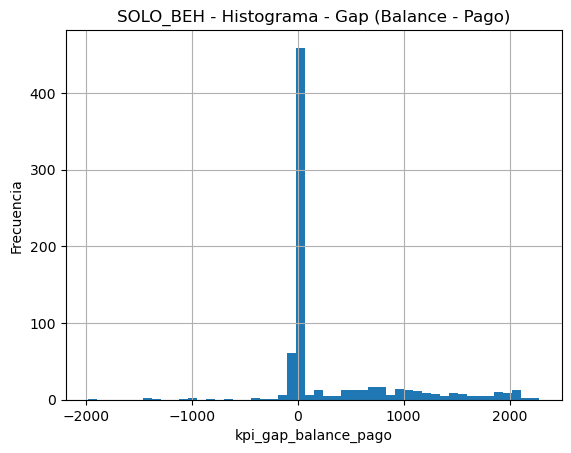

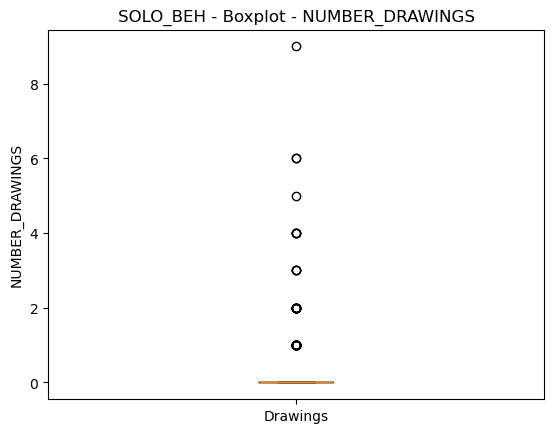

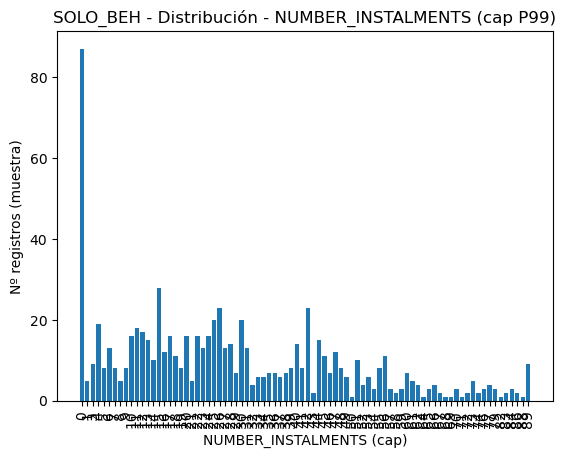

In [32]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# =========================
# 0) INPUT
# =========================
df_in = only_behavioural_df

# (opcional) ver columnas disponibles
# print(df_in.columns)

# =========================
# 1) KPIs (solo con columnas que existen en only_behavioural_df)
# =========================
df_kpi = (
    df_in
    .withColumn(
        "kpi_utilizacion_credito",
        F.when(F.col("CREDIT_CARD_LIMIT") > 0,
               F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_ratio_atm",
        F.when(F.col("NUMBER_DRAWINGS") > 0,
               F.col("NUMBER_DRAWINGS_ATM") / F.col("NUMBER_DRAWINGS")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_gap_balance_pago",
        F.col("CREDICT_CARD_BALANCE") - F.col("CREDIT_CARD_PAYMENT")
    )
    .withColumn("kpi_instalments", F.col("NUMBER_INSTALMENTS"))
)

# =========================
# 2) Muestreo para plot (seguro para datasets grandes)
# =========================
cols_plot = [
    "CREDIT_CARD_LIMIT", "CREDICT_CARD_BALANCE", "CREDIT_CARD_PAYMENT",
    "NUMBER_DRAWINGS", "NUMBER_DRAWINGS_ATM", "NUMBER_INSTALMENTS",
    "kpi_utilizacion_credito", "kpi_ratio_atm", "kpi_gap_balance_pago"
]

df_sample = (
    df_kpi.select(*cols_plot)
    .sample(withReplacement=False, fraction=0.02, seed=42)  # ajusta 0.005 si va lento
    .limit(200_000)
)

pdf = df_sample.toPandas()

def _clean(s):
    return s.dropna()

# =========================
# 3) PLOTS
# =========================

# 3.1 Histograma - Utilización de crédito
plt.figure()
_clean(pdf["kpi_utilizacion_credito"]).hist(bins=50)
plt.title("SOLO_BEH - Histograma - Utilización de crédito (balance/límite)")
plt.xlabel("kpi_utilizacion_credito")
plt.ylabel("Frecuencia")
plt.show()

# 3.2 Scatter - Límite vs Balance
plt.figure()
mask = pdf["CREDIT_CARD_LIMIT"].notna() & pdf["CREDICT_CARD_BALANCE"].notna()
plt.scatter(pdf.loc[mask, "CREDIT_CARD_LIMIT"], pdf.loc[mask, "CREDICT_CARD_BALANCE"], s=5)
plt.title("SOLO_BEH - Scatter - Límite vs Balance")
plt.xlabel("CREDIT_CARD_LIMIT")
plt.ylabel("CREDICT_CARD_BALANCE")
plt.show()

# 3.3 Histograma - Ratio ATM
plt.figure()
_clean(pdf["kpi_ratio_atm"]).hist(bins=50)
plt.title("SOLO_BEH - Histograma - Ratio ATM (ATM/total)")
plt.xlabel("kpi_ratio_atm")
plt.ylabel("Frecuencia")
plt.show()

# 3.4 Histograma - Gap (Balance - Pago)
plt.figure()
_clean(pdf["kpi_gap_balance_pago"]).hist(bins=50)
plt.title("SOLO_BEH - Histograma - Gap (Balance - Pago)")
plt.xlabel("kpi_gap_balance_pago")
plt.ylabel("Frecuencia")
plt.show()

# 3.5 Boxplot - NUMBER_DRAWINGS
plt.figure()
plt.boxplot(_clean(pdf["NUMBER_DRAWINGS"]), vert=True, showfliers=True)
plt.title("SOLO_BEH - Boxplot - NUMBER_DRAWINGS")
plt.ylabel("NUMBER_DRAWINGS")
plt.xticks([1], ["Drawings"])
plt.show()

# 3.6 Bar - NUMBER_INSTALMENTS (cap P99)
plt.figure()
v = _clean(pdf["NUMBER_INSTALMENTS"]).astype(int)
cap = int(v.quantile(0.99)) if len(v) > 0 else 0
v2 = v.clip(upper=cap)
counts = v2.value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.title("SOLO_BEH - Distribución - NUMBER_INSTALMENTS (cap P99)")
plt.xlabel("NUMBER_INSTALMENTS (cap)")
plt.ylabel("Nº registros (muestra)")
plt.xticks(rotation=90)
plt.show()
